In [ ]:
# =============================================================================
# CELL 1 — Monte Carlo GP Assignment with District Constraint
# =============================================================================
#
# Purpose:
#   Revised version of monte_carlo_gp_assignment.ipynb incorporating the
#   DHS admin2 displacement constraint. Per the DHS GPS displacement README,
#   cluster displacement is restricted to stay within the same admin2
#   (district) area. The original notebook omitted this constraint, meaning
#   simulated points could cross district boundaries — producing pessimistic
#   P(primary GP) values, particularly for border clusters.
#
#   This notebook uses official SHRUG PC11 district boundary polygons
#   rather than dissolving village polygons, for more accurate district
#   boundaries.
#
#   Key methodological changes from monte_carlo_gp_assignment.ipynb:
#   - District constraint applied: simulated points outside the cluster's
#     district are discarded before GP assignment
#   - Probabilities normalised by n_in_district (valid draws within district)
#     rather than n_simulations (total draws)
#   - Official SHRUG PC11 district polygons used for district boundaries
#
# Structure:
#   Cells 1-13:  Ganganagar pilot (verify district constraint is working)
#   Cells 14-22: Full Rajasthan
#   Cells 23-31: Full Uttar Pradesh
#
# Outputs saved to same folders as monte_carlo_gp_assignment.ipynb
# but with "_constrained" suffix in filenames.

In [1]:
# =============================================================================
# CELL 2 — Imports and Paths
# =============================================================================

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print(f"geopandas: {gpd.__version__}")
print(f"pandas:    {pd.__version__}")
print(f"numpy:     {np.__version__}")

# ── Relative paths ────────────────────────────────────────────────────────────
DATA_DIR = Path("../data")

NFHS4_GPS_PATH     = DATA_DIR / "nfhs4" / "nfhs4_gps_clusters.shp"
NFHS5_GPS_PATH     = DATA_DIR / "nfhs5" / "nfhs5_gps_clusters.shp"
RJ_VILLAGES_PATH   = DATA_DIR / "shrug rajasthan village polygons" / "shrug_rajasthan_villages.shp"
UP_VILLAGES_PART1  = DATA_DIR / "shrug uttar pradesh village polygons" / "shrug_up_villages_part1.shp"
UP_VILLAGES_PART2  = DATA_DIR / "shrug uttar pradesh village polygons" / "shrug_up_villages_part2.shp"
SHRUG_LGD_PATH     = DATA_DIR / "shrug_LGD_matched.csv"
DISTRICT_POLY_PATH = DATA_DIR / "shrug-pc11dist-poly-shp" / "district.shp"

# ── Verify all required files exist ───────────────────────────────────────────
print("\nChecking required files:")
all_found = True
for path in [NFHS4_GPS_PATH, NFHS5_GPS_PATH, RJ_VILLAGES_PATH,
             UP_VILLAGES_PART1, UP_VILLAGES_PART2,
             SHRUG_LGD_PATH, DISTRICT_POLY_PATH]:
    status = "✓" if path.exists() else "✗ NOT FOUND"
    if not path.exists():
        all_found = False
    print(f"  {status}  {path}")

print("\nAll files found." if all_found else "\nSome files missing.")

# ── Constants ─────────────────────────────────────────────────────────────────
PROJECTED_CRS      = "EPSG:32644"   # UTM Zone 44N (metres)
PILOT_DISTRICT     = "099"          # Ganganagar, Rajasthan
PILOT_STATE        = "08"           # Rajasthan
N_SIMULATIONS      = 1000
RANDOM_SEED        = 42
RURAL_DISPLACEMENT = 5000           # metres
URBAN_DISPLACEMENT = 2000           # metres

geopandas: 1.1.3
pandas:    3.0.2
numpy:     1.26.4

Checking required files:
  ✓  ../data/nfhs4/nfhs4_gps_clusters.shp
  ✓  ../data/nfhs5/nfhs5_gps_clusters.shp
  ✓  ../data/shrug rajasthan village polygons/shrug_rajasthan_villages.shp
  ✓  ../data/shrug uttar pradesh village polygons/shrug_up_villages_part1.shp
  ✓  ../data/shrug uttar pradesh village polygons/shrug_up_villages_part2.shp
  ✓  ../data/shrug_LGD_matched.csv
  ✓  ../data/shrug-pc11dist-poly-shp/district.shp

All files found.


In [2]:
# =============================================================================
# CELL 3 — Load SHRUG District Polygons
# =============================================================================
# Using official SHRUG PC11 district boundary polygons rather than
# dissolving village polygons — more accurate at district edges and
# not affected by GP polygon coverage gaps.

print("Loading SHRUG district polygons...")
districts = gpd.read_file(DISTRICT_POLY_PATH)
print(f"Total districts (all India): {len(districts)}")
print(f"Columns: {districts.columns.tolist()}")
print(f"\nSample rows:")
print(districts.head(5))

# Reproject to metres
districts = districts.to_crs(PROJECTED_CRS)
print(f"\nCRS: {districts.crs}")

Loading SHRUG district polygons...
Total districts (all India): 641
Columns: ['pc11_s_id', 'pc11_d_id', 'd_name', 'geometry']

Sample rows:
  pc11_s_id pc11_d_id        d_name  \
0        24       468       Kachchh   
1        24       469  Banas Kantha   
2        24       470         Patan   
3        24       471      Mahesana   
4        24       472  Sabar Kantha   

                                            geometry  
0  MULTIPOLYGON (((70.45008 23.01226, 70.44904 23...  
1  MULTIPOLYGON (((71.24964 24.20926, 71.24207 24...  
2  MULTIPOLYGON (((71.42507 23.96967, 71.42497 23...  
3  POLYGON ((72.79975 24.07615, 72.80022 24.07529...  
4  POLYGON ((73.14784 24.47759, 73.14773 24.4741,...  

CRS: EPSG:32644


In [3]:
# =============================================================================
# CELL 4 — Load SHRUG-LGD Crosswalk
# =============================================================================

print("Loading SHRUG-LGD crosswalk...")
shrug_lgd = pd.read_csv(SHRUG_LGD_PATH, encoding="latin-1", low_memory=False)

def get_gp_code(row):
    if row["gp_to_urban_conversion"] == "Yes" and pd.notna(row["old_gp_lgd_code"]):
        return row["old_gp_lgd_code"]
    elif pd.notna(row["LGD_code"]) and row["local_body_type"] == "Gram Panchayat":
        return row["LGD_code"]
    return None

def get_gp_name(row):
    if row["gp_to_urban_conversion"] == "Yes" and pd.notna(row["old_gp_name"]):
        return row["old_gp_name"]
    elif pd.notna(row["local_body_name"]) and row["local_body_type"] == "Gram Panchayat":
        return row["local_body_name"]
    return None

shrug_lgd["gp_lgd_code"] = shrug_lgd.apply(get_gp_code, axis=1)
shrug_lgd["gp_name"]     = shrug_lgd.apply(get_gp_name, axis=1)

lgd_gp = shrug_lgd[shrug_lgd["gp_lgd_code"].notna()][
    ["shrid2", "gp_lgd_code", "gp_name"]
].copy().rename(columns={"shrid2": "shrid2_key"})

print(f"Rows with valid GP code: {len(lgd_gp)}")

Loading SHRUG-LGD crosswalk...
Rows with valid GP code: 526244


In [4]:
# =============================================================================
# CELL 5 — Load and Prepare Ganganagar Village Polygons
# =============================================================================

print("Loading Rajasthan village polygons...")
rj_villages = gpd.read_file(RJ_VILLAGES_PATH).to_crs(PROJECTED_CRS)

# Filter to Ganganagar
ganganagar_villages = rj_villages[
    rj_villages["pc11_d_id"] == PILOT_DISTRICT
].copy()
print(f"Ganganagar villages: {len(ganganagar_villages)}")

# Assign GP codes
ganganagar_villages["shrid2_key"] = (
    "11-" +
    ganganagar_villages["pc11_s_id"].astype(str).str.zfill(2)  + "-" +
    ganganagar_villages["pc11_d_id"].astype(str).str.zfill(3)  + "-" +
    ganganagar_villages["pc11_sd_id"].astype(str).str.zfill(5) + "-" +
    ganganagar_villages["pc11_tv_id"].astype(str).str.zfill(6)
)
ganganagar_villages = ganganagar_villages.merge(lgd_gp, on="shrid2_key", how="left")

matched = ganganagar_villages["gp_lgd_code"].notna().mean()
print(f"Villages with GP code: {ganganagar_villages['gp_lgd_code'].notna().sum()} ({matched:.1%})")
print(f"Unique GPs: {ganganagar_villages['gp_lgd_code'].nunique()}")

Loading Rajasthan village polygons...
Ganganagar villages: 3034
Villages with GP code: 2840 (93.6%)
Unique GPs: 343


In [5]:
# =============================================================================
# CELL 6 — Dissolve to GP Polygons and Get Ganganagar District Polygon
# =============================================================================

# GP polygons
print("Dissolving to GP polygons...")
gp_polygons = (
    ganganagar_villages[ganganagar_villages["gp_lgd_code"].notna()]
    .dissolve(by="gp_lgd_code", as_index=False)
    [["gp_lgd_code", "gp_name", "geometry"]]
)
print(f"GP polygons: {len(gp_polygons)}")

invalid = (~gp_polygons.geometry.is_valid).sum()
if invalid > 0:
    gp_polygons["geometry"] = gp_polygons.geometry.buffer(0)
print(f"Invalid geometries: {invalid}")

# Get Ganganagar district polygon from official SHRUG district file
# Check what the district identifier column is called
print(f"\nDistrict polygon columns: {districts.columns.tolist()}")

# Filter to Ganganagar — identify correct column after seeing output above
# (likely pc11_d_id or similar)
ganganagar_district = districts[
    (districts["pc11_s_id"] == PILOT_STATE) &
    (districts["pc11_d_id"] == PILOT_DISTRICT)
].copy()

print(f"Ganganagar district polygon rows: {len(ganganagar_district)}")
print(ganganagar_district)

Dissolving to GP polygons...
GP polygons: 343
Invalid geometries: 0

District polygon columns: ['pc11_s_id', 'pc11_d_id', 'd_name', 'geometry']
Ganganagar district polygon rows: 1
    pc11_s_id pc11_d_id      d_name  \
200        08       099  Ganganagar   

                                              geometry  
200  POLYGON ((-184421.778 3345975.041, -184890.851...  


In [6]:
# =============================================================================
# CELL 7 — Load NFHS Clusters for Ganganagar
# =============================================================================

def load_clusters_ganganagar(path, round_name):
    print(f"\nLoading {round_name}...")
    gdf = gpd.read_file(path)
    gdf = gdf[["DHSCLUST", "LATNUM", "LONGNUM",
                "URBAN_RURA", "ADM1NAME", "DHSREGNA"]].copy()
    gdf["ADM1NAME"] = gdf["ADM1NAME"].str.strip().str.upper()
    gdf = gdf[(gdf["LATNUM"] != 0) & (gdf["LONGNUM"] != 0)].copy()
    gdf = gdf[gdf["DHSREGNA"].str.upper().str.contains("GANGANAGAR")].copy()
    gdf["round"] = round_name
    gdf = gpd.GeoDataFrame(
        gdf,
        geometry=gpd.points_from_xy(gdf.LONGNUM, gdf.LATNUM),
        crs="EPSG:4326"
    ).to_crs(PROJECTED_CRS)
    print(f"  Clusters: {len(gdf)}")
    print(gdf["URBAN_RURA"].value_counts().to_string())
    return gdf

nfhs4_ganganagar = load_clusters_ganganagar(NFHS4_GPS_PATH, "NFHS4")
nfhs5_ganganagar = load_clusters_ganganagar(NFHS5_GPS_PATH, "NFHS5")


Loading NFHS4...
  Clusters: 43
URBAN_RURA
R    31
U    12

Loading NFHS5...
  Clusters: 45
URBAN_RURA
R    33
U    12


In [14]:
# =============================================================================
# CELL 8 — Monte Carlo GP Assignment Function with District Constraint
# =============================================================================

def run_monte_carlo_constrained(clusters, gp_polygons, district_polygons,
                                 n_simulations, random_seed):
    np.random.seed(random_seed)
    results = []

    print(f"Running constrained Monte Carlo ({n_simulations} sims per cluster)...")
    print(f"Clusters to process: {len(clusters)}")

    for i, (_, cluster) in enumerate(clusters.iterrows()):
        if i % 10 == 0:
            print(f"  Processing cluster {i+1}/{len(clusters)}...")

        R = RURAL_DISPLACEMENT if cluster["URBAN_RURA"] == "R" \
            else URBAN_DISPLACEMENT

        angles    = np.random.uniform(0, 2 * np.pi, n_simulations)
        distances = np.random.uniform(0, R, n_simulations)
        cx = cluster.geometry.x
        cy = cluster.geometry.y
        sim_x = cx + distances * np.cos(angles)
        sim_y = cy + distances * np.sin(angles)

        sim_points = gpd.GeoDataFrame(
            {"sim_id": range(n_simulations)},
            geometry=gpd.points_from_xy(sim_x, sim_y),
            crs=PROJECTED_CRS
        )

        # ── District constraint ───────────────────────────────────────────────
        # Find which district this cluster belongs to using sjoin_nearest
        # This handles cases where the displaced GPS point falls just outside
        # the SHRUG district boundary due to boundary source mismatch between
        # DHS admin2 and SHRUG 2011 Census districts

        cluster_gdf = gpd.GeoDataFrame(
            [{"geometry": cluster.geometry}],
            crs=PROJECTED_CRS
        )
        nearest_district = gpd.sjoin_nearest(
            cluster_gdf,
            district_polygons[["pc11_d_id", "geometry"]],
            how="left"
        )

        if len(nearest_district) > 0:
            assigned_district_id = nearest_district["pc11_d_id"].iloc[0]
            district_geom = district_polygons[
                district_polygons["pc11_d_id"] == assigned_district_id
            ].geometry.iloc[0]
            in_district_mask = sim_points.geometry.within(district_geom)
            sim_valid = sim_points[in_district_mask].copy()
        else:
            sim_valid = sim_points.copy()

        n_in_district      = len(sim_valid)
        n_outside_district = n_simulations - n_in_district

        if n_in_district == 0:
            results.append({
                "DHSCLUST":            cluster["DHSCLUST"],
                "URBAN_RURA":          cluster["URBAN_RURA"],
                "DHSREGNA":            cluster["DHSREGNA"],
                "round":               cluster["round"],
                "displacement_R_m":    R,
                "primary_gp":          None,
                "primary_gp_prob":     0.0,
                "n_gps_hit":           0,
                "n_in_district":       0,
                "n_outside_district":  n_outside_district,
                "n_outside_any_gp":    n_simulations,
                "gp_distribution":     {},
            })
            continue

        # ── GP assignment ─────────────────────────────────────────────────────
        joined = gpd.sjoin(
            sim_valid,
            gp_polygons[["gp_lgd_code", "gp_name", "geometry"]],
            how="left",
            predicate="within"
        )

        gp_counts    = joined["gp_lgd_code"].value_counts()
        n_outside_gp = joined["gp_lgd_code"].isna().sum()

        primary_gp      = gp_counts.index[0] if len(gp_counts) > 0 else None
        primary_gp_prob = (gp_counts.iloc[0] / n_in_district
                           if len(gp_counts) > 0 else 0.0)

        results.append({
            "DHSCLUST":            cluster["DHSCLUST"],
            "URBAN_RURA":          cluster["URBAN_RURA"],
            "DHSREGNA":            cluster["DHSREGNA"],
            "round":               cluster["round"],
            "displacement_R_m":    R,
            "primary_gp":          primary_gp,
            "primary_gp_prob":     round(primary_gp_prob, 4),
            "n_gps_hit":           len(gp_counts),
            "n_in_district":       n_in_district,
            "n_outside_district":  n_outside_district,
            "n_outside_any_gp":    n_outside_gp,
            "gp_distribution":     dict(gp_counts),
        })

    return pd.DataFrame(results)

print("run_monte_carlo_constrained function updated with sjoin_nearest district fix.")

run_monte_carlo_constrained function updated with sjoin_nearest district fix.


In [15]:
# =============================================================================
# CELL 9 — Run Monte Carlo for Ganganagar (with district constraint)
# =============================================================================

print("Running constrained Monte Carlo for Ganganagar...")

mc_nfhs4 = run_monte_carlo_constrained(
    nfhs4_ganganagar, gp_polygons, ganganagar_district,
    N_SIMULATIONS, RANDOM_SEED
)
mc_nfhs5 = run_monte_carlo_constrained(
    nfhs5_ganganagar, gp_polygons, ganganagar_district,
    N_SIMULATIONS, RANDOM_SEED
)

print("\nDone.")
print(f"\nNew columns available: {mc_nfhs4.columns.tolist()}")

Running constrained Monte Carlo for Ganganagar...
Running constrained Monte Carlo (1000 sims per cluster)...
Clusters to process: 43
  Processing cluster 1/43...
  Processing cluster 11/43...
  Processing cluster 21/43...
  Processing cluster 31/43...
  Processing cluster 41/43...
Running constrained Monte Carlo (1000 sims per cluster)...
Clusters to process: 45
  Processing cluster 1/45...
  Processing cluster 11/45...
  Processing cluster 21/45...
  Processing cluster 31/45...
  Processing cluster 41/45...

Done.

New columns available: ['DHSCLUST', 'URBAN_RURA', 'DHSREGNA', 'round', 'displacement_R_m', 'primary_gp', 'primary_gp_prob', 'n_gps_hit', 'n_in_district', 'n_outside_district', 'n_outside_any_gp', 'gp_distribution']


In [16]:
# =============================================================================
# CELL 10 — Summary Statistics: Ganganagar
# =============================================================================

def summarise_mc(mc_df, round_name, location="Ganganagar"):
    rural = mc_df[mc_df["URBAN_RURA"] == "R"].copy()
    print(f"\n── {round_name} rural clusters — {location} ──")
    print(f"Total clusters:                    {len(rural)}")
    print(f"Mean P(primary GP):                {rural['primary_gp_prob'].mean():.3f}")
    print(f"Median P(primary GP):              {rural['primary_gp_prob'].median():.3f}")
    print(f"Clusters with P > 0.8:             "
          f"{(rural['primary_gp_prob'] > 0.8).sum()} "
          f"({(rural['primary_gp_prob'] > 0.8).mean():.1%})")
    print(f"Clusters with P > 0.5:             "
          f"{(rural['primary_gp_prob'] > 0.5).sum()} "
          f"({(rural['primary_gp_prob'] > 0.5).mean():.1%})")
    print(f"Mean GPs hit per cluster:          {rural['n_gps_hit'].mean():.2f}")
    print(f"Mean sims outside district:        {rural['n_outside_district'].mean():.1f}")
    print(f"Mean sims outside any GP:          {rural['n_outside_any_gp'].mean():.1f}")
    print(f"\nP(primary GP) distribution:")
    bins   = [0, 0.25, 0.5, 0.75, 0.9, 1.01]
    labels = ["0-25%", "25-50%", "50-75%", "75-90%", ">90%"]
    rural["prob_bin"] = pd.cut(rural["primary_gp_prob"], bins=bins, labels=labels)
    print(rural["prob_bin"].value_counts().sort_index().to_string())

summarise_mc(mc_nfhs4, "NFHS4")
summarise_mc(mc_nfhs5, "NFHS5")


── NFHS4 rural clusters — Ganganagar ──
Total clusters:                    31
Mean P(primary GP):                0.417
Median P(primary GP):              0.387
Clusters with P > 0.8:             1 (3.2%)
Clusters with P > 0.5:             5 (16.1%)
Mean GPs hit per cluster:          7.90
Mean sims outside district:        61.8
Mean sims outside any GP:          64.7

P(primary GP) distribution:
prob_bin
0-25%      0
25-50%    26
50-75%     4
75-90%     0
>90%       1

── NFHS5 rural clusters — Ganganagar ──
Total clusters:                    33
Mean P(primary GP):                0.393
Median P(primary GP):              0.384
Clusters with P > 0.8:             0 (0.0%)
Clusters with P > 0.5:             3 (9.1%)
Mean GPs hit per cluster:          8.06
Mean sims outside district:        79.5
Mean sims outside any GP:          77.3

P(primary GP) distribution:
prob_bin
0-25%      1
25-50%    28
50-75%     3
75-90%     0
>90%       0


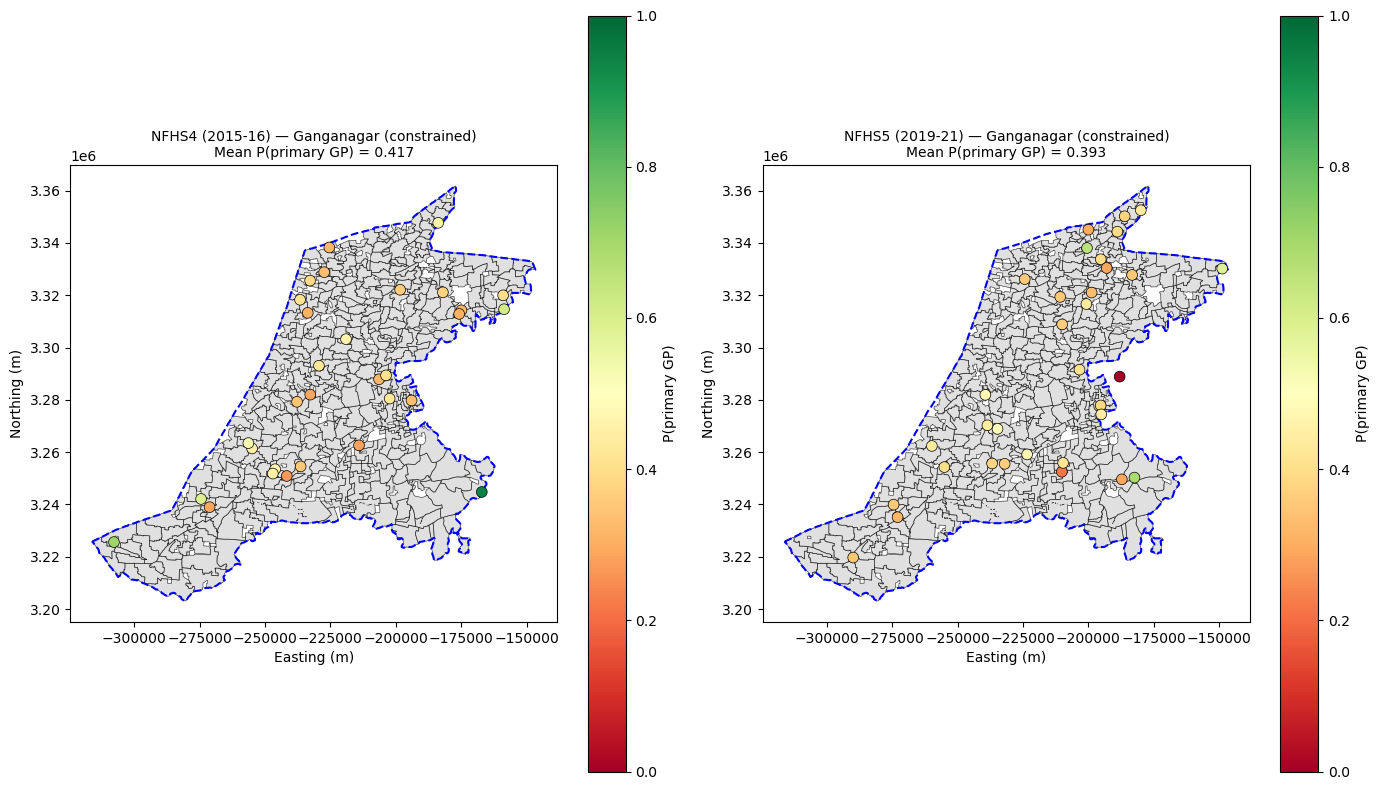

Map saved.


In [17]:
# =============================================================================
# CELL 11 — District-Level Map: Ganganagar
# =============================================================================

OUTPUT_GANG = Path("../outputs/monte carlo simulation ganganagar")
OUTPUT_GANG.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for ax, mc_df, clusters_gdf, round_name in [
    (axes[0], mc_nfhs4, nfhs4_ganganagar, "NFHS4 (2015-16)"),
    (axes[1], mc_nfhs5, nfhs5_ganganagar, "NFHS5 (2019-21)")
]:
    # Plot district boundary
    ganganagar_district.plot(ax=ax, color="none",
                              edgecolor="blue", linewidth=1.5,
                              linestyle="--", zorder=3)
    # Plot GP boundaries
    gp_polygons.plot(ax=ax, color="lightgrey",
                     edgecolor="black", linewidth=0.5, alpha=0.7)

    rural = mc_df[mc_df["URBAN_RURA"] == "R"]
    clusters_plot = clusters_gdf[clusters_gdf["URBAN_RURA"] == "R"].merge(
        rural[["DHSCLUST", "primary_gp_prob", "n_gps_hit",
               "n_outside_district"]],
        on="DHSCLUST", how="left"
    )

    scatter = ax.scatter(
        clusters_plot.geometry.x,
        clusters_plot.geometry.y,
        c=clusters_plot["primary_gp_prob"],
        cmap="RdYlGn", vmin=0, vmax=1,
        s=60, edgecolors="black", linewidth=0.5, zorder=5
    )
    plt.colorbar(scatter, ax=ax, label="P(primary GP)")
    ax.set_title(
        f"{round_name} — Ganganagar (constrained)\n"
        f"Mean P(primary GP) = "
        f"{rural['primary_gp_prob'].mean():.3f}",
        fontsize=10
    )
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")

plt.tight_layout()
plt.savefig(OUTPUT_GANG / "ganganagar_monte_carlo_constrained.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Map saved.")

Generating zoomed-in hand-check maps...
  High confidence cluster


/var/folders/y2/8vsyj51969sfs7y5l1yxhl000000gq/T/ipykernel_89231/2664122767.py:65: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(fontsize=8)


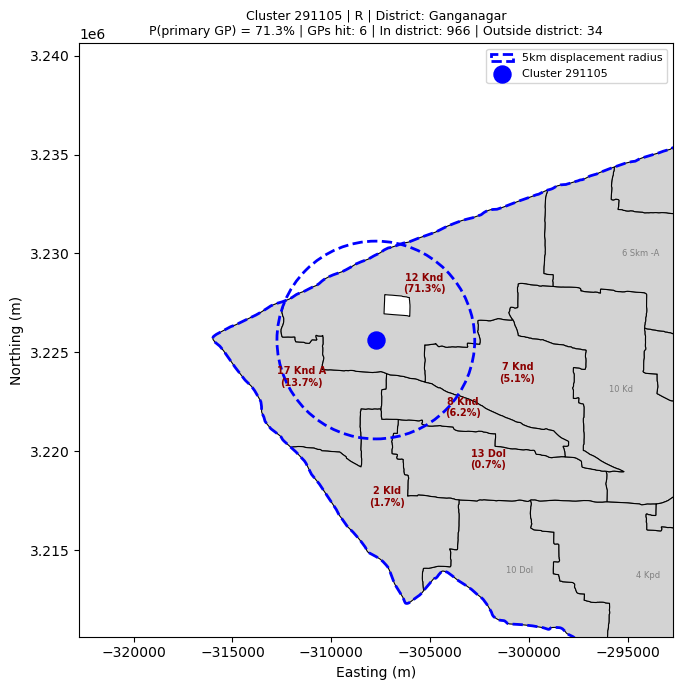

  Medium confidence cluster


/var/folders/y2/8vsyj51969sfs7y5l1yxhl000000gq/T/ipykernel_89231/2664122767.py:65: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(fontsize=8)


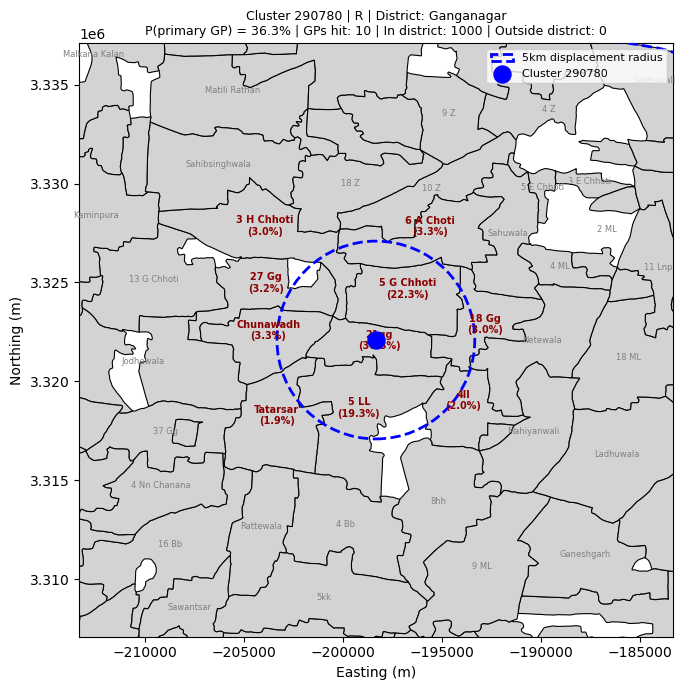

  Low confidence / border cluster


/var/folders/y2/8vsyj51969sfs7y5l1yxhl000000gq/T/ipykernel_89231/2664122767.py:65: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(fontsize=8)


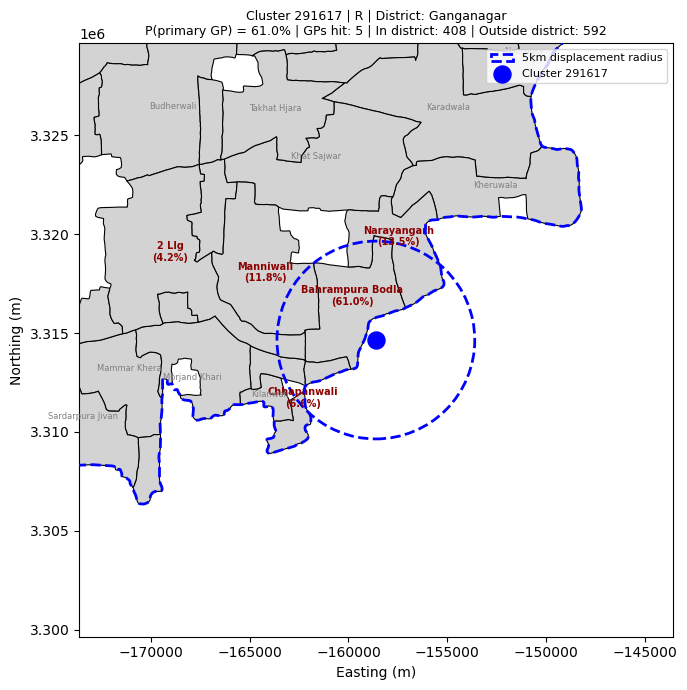

In [18]:
# =============================================================================
# CELL 12 — Zoomed-In Cluster Detail Maps for Hand-Checking
# =============================================================================

def plot_cluster_detail(dhsclust, mc_df, clusters_gdf, gp_polygons,
                         district_polygon, label=""):
    """Zoomed-in map verifying district constraint is working correctly."""
    mc_row  = mc_df[mc_df["DHSCLUST"] == dhsclust].iloc[0]
    cluster = clusters_gdf[clusters_gdf["DHSCLUST"] == dhsclust].iloc[0]

    cx, cy = cluster.geometry.x, cluster.geometry.y
    R = RURAL_DISPLACEMENT if cluster["URBAN_RURA"] == "R" \
        else URBAN_DISPLACEMENT

    margin = R * 3
    bbox   = (cx - margin, cy - margin, cx + margin, cy + margin)
    gps_nearby = gp_polygons.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]

    fig, ax = plt.subplots(1, 1, figsize=(7, 7))

    # Plot GP boundaries
    gps_nearby.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.8)

    # Plot district boundary
    district_polygon.plot(ax=ax, color="none", edgecolor="blue",
                           linewidth=2, linestyle="--", zorder=4,
                           label="District boundary")

    # Label GPs with probabilities
    gp_dist = mc_row["gp_distribution"]
    for _, gp in gps_nearby.iterrows():
        prob     = gp_dist.get(gp["gp_lgd_code"], 0) / mc_row["n_in_district"] \
                   if mc_row["n_in_district"] > 0 else 0
        centroid = gp.geometry.centroid
        if prob > 0:
            ax.annotate(f"{gp['gp_name']}\n({prob:.1%})",
                        xy=(centroid.x, centroid.y),
                        fontsize=7, ha="center",
                        color="darkred", fontweight="bold")
        else:
            ax.annotate(gp["gp_name"],
                        xy=(centroid.x, centroid.y),
                        fontsize=6, ha="center", color="grey")

    # Displacement circle
    circle = plt.Circle((cx, cy), R, color="blue", fill=False,
                          linewidth=2, linestyle="--",
                          label=f"{R/1000:.0f}km displacement radius")
    ax.add_patch(circle)

    ax.scatter(cx, cy, color="blue", s=150, zorder=5,
               label=f"Cluster {int(dhsclust)}")

    ax.set_xlim(bbox[0], bbox[2])
    ax.set_ylim(bbox[1], bbox[3])
    ax.set_title(
        f"Cluster {int(dhsclust)} | {mc_row['URBAN_RURA']} | "
        f"District: {mc_row['DHSREGNA']}\n"
        f"P(primary GP) = {mc_row['primary_gp_prob']:.1%} | "
        f"GPs hit: {mc_row['n_gps_hit']} | "
        f"In district: {mc_row['n_in_district']} | "
        f"Outside district: {mc_row['n_outside_district']}",
        fontsize=9
    )
    ax.legend(fontsize=8)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    plt.tight_layout()

    filename = f"cluster_{int(dhsclust)}_{label}_constrained.png" \
               if label else f"cluster_{int(dhsclust)}_constrained.png"
    plt.savefig(OUTPUT_GANG / filename, dpi=150, bbox_inches="tight")
    plt.show()

print("Generating zoomed-in hand-check maps...")
print("  High confidence cluster")
plot_cluster_detail(291105.0, mc_nfhs4, nfhs4_ganganagar, gp_polygons,
                    ganganagar_district, label="high_confidence")
print("  Medium confidence cluster")
plot_cluster_detail(290780.0, mc_nfhs4, nfhs4_ganganagar, gp_polygons,
                    ganganagar_district, label="medium_confidence")
print("  Low confidence / border cluster")
plot_cluster_detail(291617.0, mc_nfhs4, nfhs4_ganganagar, gp_polygons,
                    ganganagar_district, label="low_confidence_border")

In [12]:
# =============================================================================
# CELL 13 — Save Ganganagar Results
# =============================================================================

mc_nfhs4.to_csv(OUTPUT_GANG / "ganganagar_mc_nfhs4_constrained.csv", index=False)
mc_nfhs5.to_csv(OUTPUT_GANG / "ganganagar_mc_nfhs5_constrained.csv", index=False)

print("Saved:")
print(f"  {OUTPUT_GANG / 'ganganagar_mc_nfhs4_constrained.csv'}")
print(f"  {OUTPUT_GANG / 'ganganagar_mc_nfhs5_constrained.csv'}")
print(f"\nRows: NFHS4={len(mc_nfhs4)}, NFHS5={len(mc_nfhs5)}")
print("\nVerify outputs then proceed to full Rajasthan (Cells 14+)")

Saved:
  ../outputs/monte carlo simulation ganganagar/ganganagar_mc_nfhs4_constrained.csv
  ../outputs/monte carlo simulation ganganagar/ganganagar_mc_nfhs5_constrained.csv

Rows: NFHS4=43, NFHS5=45

Verify outputs then proceed to full Rajasthan (Cells 14+)


Lowest P cluster in NFHS5:
  DHSCLUST:           9924.0
  P(primary GP):      0.0%
  n_in_district:      0
  n_outside_district: 1000
  n_outside_any_gp:   1000
  GPs hit:            0
  GP distribution:    {}


/var/folders/y2/8vsyj51969sfs7y5l1yxhl000000gq/T/ipykernel_89231/2664122767.py:65: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(fontsize=8)


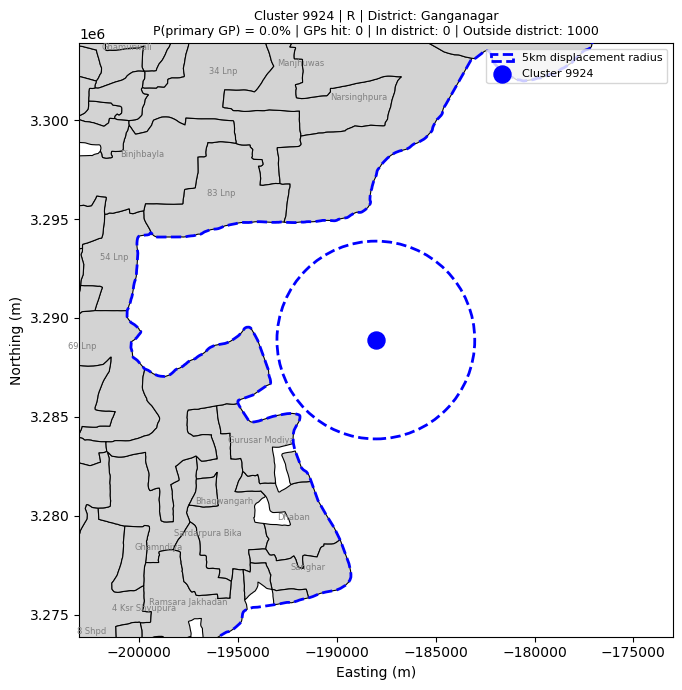

In [19]:
# Find the lone red NFHS5 cluster
worst = mc_nfhs5[mc_nfhs5["URBAN_RURA"] == "R"].sort_values("primary_gp_prob").iloc[0]
print(f"Lowest P cluster in NFHS5:")
print(f"  DHSCLUST:           {worst['DHSCLUST']}")
print(f"  P(primary GP):      {worst['primary_gp_prob']:.1%}")
print(f"  n_in_district:      {worst['n_in_district']}")
print(f"  n_outside_district: {worst['n_outside_district']}")
print(f"  n_outside_any_gp:   {worst['n_outside_any_gp']}")
print(f"  GPs hit:            {worst['n_gps_hit']}")
print(f"  GP distribution:    {worst['gp_distribution']}")

# Plot it
plot_cluster_detail(worst["DHSCLUST"], mc_nfhs5, nfhs5_ganganagar,
                    gp_polygons, ganganagar_district,
                    label="nfhs5_lowest_p")

In [20]:
# =============================================================================
# CELL 14 — Load All Rajasthan Village Polygons and Assign GP Codes
# =============================================================================

print("Loading all Rajasthan village polygons...")
rj_villages_all = gpd.read_file(RJ_VILLAGES_PATH).to_crs(PROJECTED_CRS)
print(f"Total Rajasthan villages: {len(rj_villages_all)}")

# Assign GP codes
rj_villages_all["shrid2_key"] = (
    "11-" +
    rj_villages_all["pc11_s_id"].astype(str).str.zfill(2)  + "-" +
    rj_villages_all["pc11_d_id"].astype(str).str.zfill(3)  + "-" +
    rj_villages_all["pc11_sd_id"].astype(str).str.zfill(5) + "-" +
    rj_villages_all["pc11_tv_id"].astype(str).str.zfill(6)
)
rj_villages_all = rj_villages_all.merge(lgd_gp, on="shrid2_key", how="left")

matched = rj_villages_all["gp_lgd_code"].notna().mean()
print(f"Villages with GP code: {rj_villages_all['gp_lgd_code'].notna().sum()} ({matched:.1%})")
print(f"Unique GPs: {rj_villages_all['gp_lgd_code'].nunique()}")

Loading all Rajasthan village polygons...
Total Rajasthan villages: 44976
Villages with GP code: 39420 (87.6%)
Unique GPs: 11107


In [21]:
# =============================================================================
# CELL 15 — Dissolve to GP Polygons and Load Rajasthan District Polygons
# =============================================================================

OUTPUT_MC_RJ = Path("../outputs/monte carlo simulation rajasthan")
OUTPUT_MC_RJ.mkdir(parents=True, exist_ok=True)

print("Dissolving village polygons to GP level (all Rajasthan)...")
gp_polygons_rj = (
    rj_villages_all[rj_villages_all["gp_lgd_code"].notna()]
    .dissolve(by="gp_lgd_code", as_index=False)
    [["gp_lgd_code", "gp_name", "geometry"]]
)
print(f"GP polygons created: {len(gp_polygons_rj)}")

invalid = (~gp_polygons_rj.geometry.is_valid).sum()
if invalid > 0:
    gp_polygons_rj["geometry"] = gp_polygons_rj.geometry.buffer(0)
print(f"Invalid geometries: {invalid}")

# Save GP polygons for reuse
gp_polygons_rj.to_file(
    OUTPUT_MC_RJ / "rajasthan_gp_polygons_constrained.gpkg",
    driver="GPKG"
)
print(f"GP polygons saved.")

# Load Rajasthan district polygons from official SHRUG file
print("\nLoading Rajasthan district polygons...")
district_polygons_rj = districts[
    districts["pc11_s_id"] == PILOT_STATE
].copy()
print(f"Rajasthan districts: {len(district_polygons_rj)}")
print(district_polygons_rj["d_name"].tolist())

Dissolving village polygons to GP level (all Rajasthan)...
GP polygons created: 11107
Invalid geometries: 0
GP polygons saved.

Loading Rajasthan district polygons...
Rajasthan districts: 33
['Ganganagar', 'Hanumangarh', 'Bikaner', 'Churu', 'Jhunjhunun', 'Alwar', 'Bharatpur', 'Dhaulpur', 'Karauli', 'Sawai Madhopur', 'Dausa', 'Jaipur', 'Sikar', 'Nagaur', 'Jodhpur', 'Jaisalmer', 'Barmer', 'Jalor', 'Sirohi', 'Pali', 'Ajmer', 'Tonk', 'Bundi', 'Bhilwara', 'Rajsamand', 'Dungarpur', 'Banswara', 'Chittaurgarh', 'Kota', 'Baran', 'Jhalawar', 'Udaipur', 'Pratapgarh']


In [22]:
# =============================================================================
# CELL 16 — Load All Rajasthan NFHS Clusters
# =============================================================================

def load_rajasthan_clusters(path, round_name):
    """Load rural Rajasthan NFHS clusters."""
    print(f"\nLoading {round_name}...")
    gdf = gpd.read_file(path)
    gdf = gdf[["DHSCLUST", "LATNUM", "LONGNUM",
                "URBAN_RURA", "ADM1NAME", "DHSREGNA"]].copy()
    gdf["ADM1NAME"] = gdf["ADM1NAME"].str.strip().str.upper()
    gdf = gdf[(gdf["LATNUM"] != 0) & (gdf["LONGNUM"] != 0)].copy()
    gdf = gdf[
        (gdf["ADM1NAME"] == "RAJASTHAN") &
        (gdf["URBAN_RURA"] == "R")
    ].copy()
    gdf["round"] = round_name
    gdf = gpd.GeoDataFrame(
        gdf,
        geometry=gpd.points_from_xy(gdf.LONGNUM, gdf.LATNUM),
        crs="EPSG:4326"
    ).to_crs(PROJECTED_CRS)
    print(f"  Rural Rajasthan clusters: {len(gdf)}")
    print(f"  Districts covered: {gdf['DHSREGNA'].nunique()}")
    return gdf

nfhs4_rj = load_rajasthan_clusters(NFHS4_GPS_PATH, "NFHS4")
nfhs5_rj = load_rajasthan_clusters(NFHS5_GPS_PATH, "NFHS5")


Loading NFHS4...
  Rural Rajasthan clusters: 1190
  Districts covered: 33

Loading NFHS5...
  Rural Rajasthan clusters: 1163
  Districts covered: 33


In [23]:
# =============================================================================
# CELL 17 — Run Monte Carlo for All Rajasthan Clusters
# =============================================================================

print("Running constrained Monte Carlo for all Rajasthan rural clusters...")
print(f"NFHS4: {len(nfhs4_rj)} clusters × {N_SIMULATIONS} simulations")
print(f"NFHS5: {len(nfhs5_rj)} clusters × {N_SIMULATIONS} simulations")

mc_nfhs4_rj = run_monte_carlo_constrained(
    nfhs4_rj, gp_polygons_rj, district_polygons_rj,
    N_SIMULATIONS, RANDOM_SEED
)
mc_nfhs5_rj = run_monte_carlo_constrained(
    nfhs5_rj, gp_polygons_rj, district_polygons_rj,
    N_SIMULATIONS, RANDOM_SEED
)

# Flag clusters with boundary mismatch (GPS outside district polygon)
n_mismatch_nfhs4 = (mc_nfhs4_rj["n_in_district"] == 0).sum()
n_mismatch_nfhs5 = (mc_nfhs5_rj["n_in_district"] == 0).sum()
print(f"\nBoundary mismatch clusters (n_in_district = 0):")
print(f"  NFHS4: {n_mismatch_nfhs4}")
print(f"  NFHS5: {n_mismatch_nfhs5}")

print("\nDone.")

Running constrained Monte Carlo for all Rajasthan rural clusters...
NFHS4: 1190 clusters × 1000 simulations
NFHS5: 1163 clusters × 1000 simulations
Running constrained Monte Carlo (1000 sims per cluster)...
Clusters to process: 1190
  Processing cluster 1/1190...
  Processing cluster 11/1190...
  Processing cluster 21/1190...
  Processing cluster 31/1190...
  Processing cluster 41/1190...
  Processing cluster 51/1190...
  Processing cluster 61/1190...
  Processing cluster 71/1190...
  Processing cluster 81/1190...
  Processing cluster 91/1190...
  Processing cluster 101/1190...
  Processing cluster 111/1190...
  Processing cluster 121/1190...
  Processing cluster 131/1190...
  Processing cluster 141/1190...
  Processing cluster 151/1190...
  Processing cluster 161/1190...
  Processing cluster 171/1190...
  Processing cluster 181/1190...
  Processing cluster 191/1190...
  Processing cluster 201/1190...
  Processing cluster 211/1190...
  Processing cluster 221/1190...
  Processing cluste

In [24]:
# =============================================================================
# CELL 18 — Summary Statistics: Full Rajasthan
# =============================================================================

print("=" * 70)
print("MONTE CARLO RESULTS (CONSTRAINED): ALL RAJASTHAN RURAL CLUSTERS")
print("=" * 70)

for name, df in [("NFHS4 (2015-16)", mc_nfhs4_rj),
                  ("NFHS5 (2019-21)", mc_nfhs5_rj)]:
    rural = df[df["URBAN_RURA"] == "R"].copy()
    print(f"\n── {name} ──────────────────────────────────────")
    print(f"Total rural clusters:              {len(rural)}")
    print(f"Boundary mismatch (excluded):      {(rural['n_in_district'] == 0).sum()}")
    print(f"Mean P(primary GP):                {rural['primary_gp_prob'].mean():.3f}")
    print(f"Median P(primary GP):              {rural['primary_gp_prob'].median():.3f}")
    print(f"Clusters with P > 0.9:             "
          f"{(rural['primary_gp_prob'] > 0.9).sum()} "
          f"({(rural['primary_gp_prob'] > 0.9).mean():.1%})")
    print(f"Clusters with P > 0.8:             "
          f"{(rural['primary_gp_prob'] > 0.8).sum()} "
          f"({(rural['primary_gp_prob'] > 0.8).mean():.1%})")
    print(f"Clusters with P > 0.5:             "
          f"{(rural['primary_gp_prob'] > 0.5).sum()} "
          f"({(rural['primary_gp_prob'] > 0.5).mean():.1%})")
    print(f"Mean GPs hit per cluster:          {rural['n_gps_hit'].mean():.2f}")
    print(f"Mean sims outside district:        {rural['n_outside_district'].mean():.1f}")
    print(f"Mean sims outside any GP:          {rural['n_outside_any_gp'].mean():.1f}")
    print(f"\nP(primary GP) distribution:")
    bins   = [0, 0.25, 0.5, 0.75, 0.9, 1.01]
    labels = ["0-25%", "25-50%", "50-75%", "75-90%", ">90%"]
    rural["prob_bin"] = pd.cut(rural["primary_gp_prob"], bins=bins, labels=labels)
    print(rural["prob_bin"].value_counts().sort_index().to_string())

print(f"\n── P(primary GP) by district (NFHS5) ──")
district_summary = (
    mc_nfhs5_rj[mc_nfhs5_rj["URBAN_RURA"] == "R"]
    .groupby("DHSREGNA")["primary_gp_prob"]
    .agg(["mean", "count"])
    .round(3)
    .sort_values("mean", ascending=False)
)
district_summary.columns = ["Mean P(primary GP)", "N clusters"]
print(district_summary.to_string())

MONTE CARLO RESULTS (CONSTRAINED): ALL RAJASTHAN RURAL CLUSTERS

── NFHS4 (2015-16) ──────────────────────────────────────
Total rural clusters:              1190
Boundary mismatch (excluded):      0
Mean P(primary GP):                0.436
Median P(primary GP):              0.411
Clusters with P > 0.9:             19 (1.6%)
Clusters with P > 0.8:             40 (3.4%)
Clusters with P > 0.5:             374 (31.4%)
Mean GPs hit per cluster:          8.18
Mean sims outside district:        51.8
Mean sims outside any GP:          92.3

P(primary GP) distribution:
prob_bin
0-25%     147
25-50%    668
50-75%    313
75-90%     42
>90%       19

── NFHS5 (2019-21) ──────────────────────────────────────
Total rural clusters:              1163
Boundary mismatch (excluded):      0
Mean P(primary GP):                0.423
Median P(primary GP):              0.396
Clusters with P > 0.9:             17 (1.5%)
Clusters with P > 0.8:             34 (2.9%)
Clusters with P > 0.5:             323 (27.8%

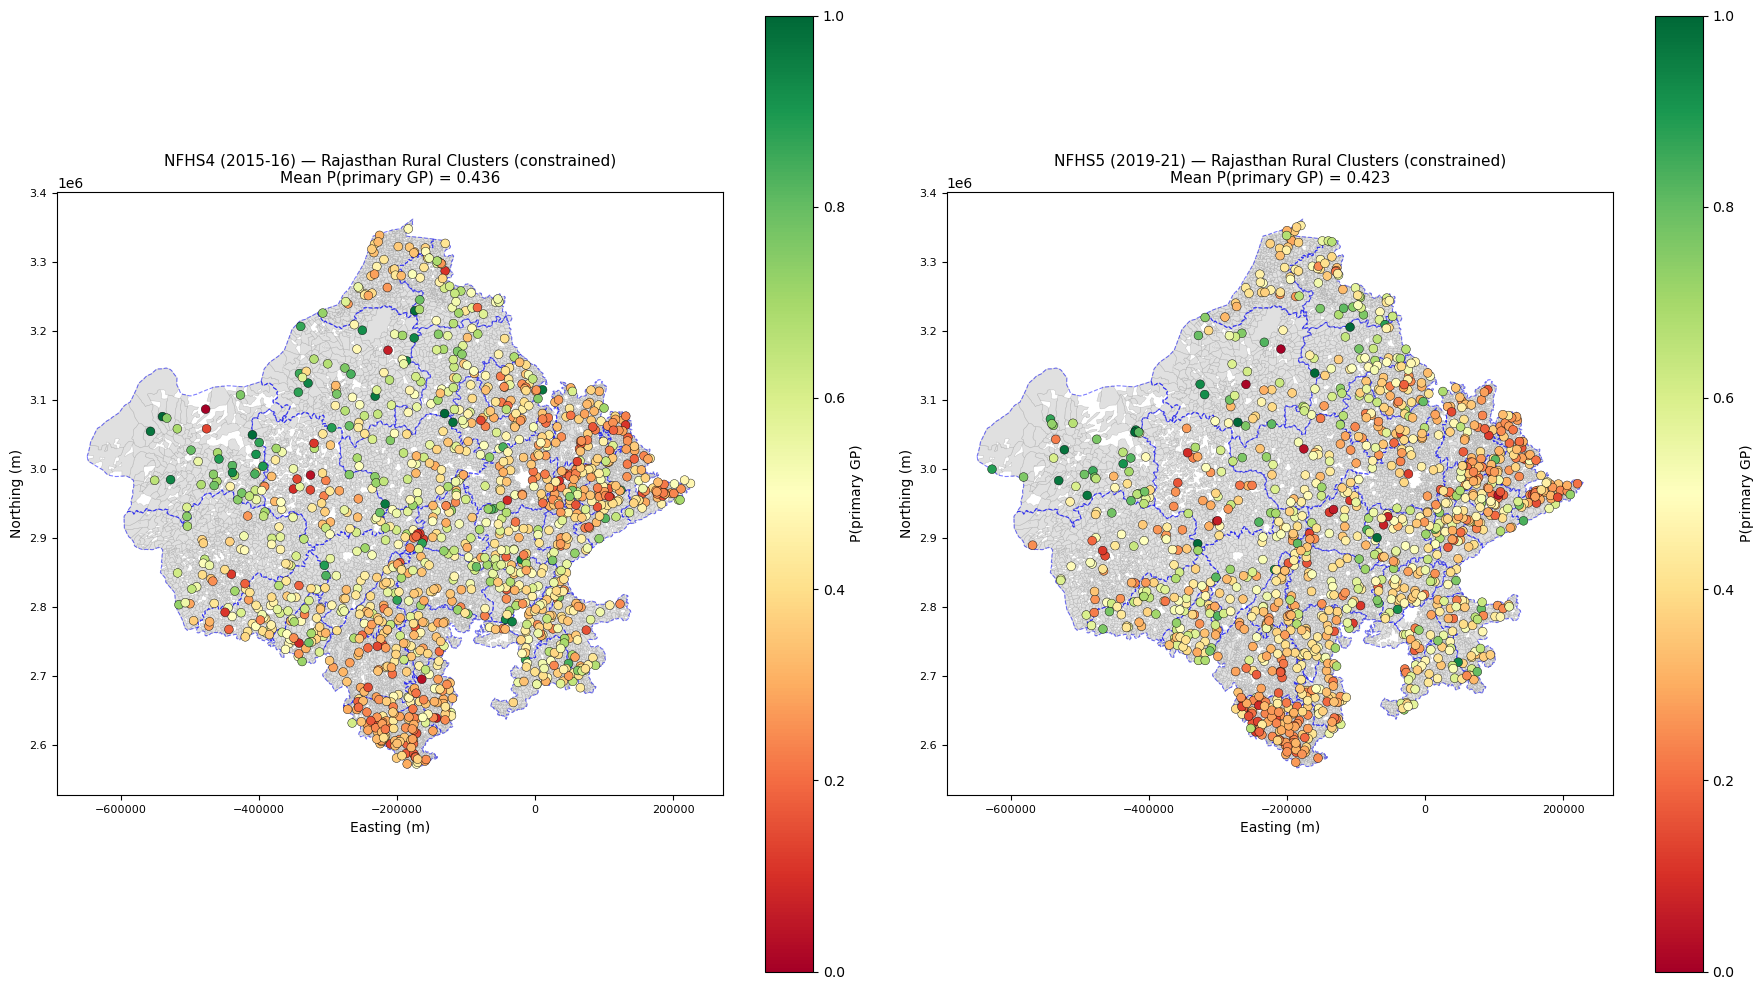

Map saved.


In [25]:
# =============================================================================
# CELL 19 — Visualisation: Full Rajasthan Map
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

for ax, mc_df, clusters_gdf, round_name in [
    (axes[0], mc_nfhs4_rj, nfhs4_rj, "NFHS4 (2015-16)"),
    (axes[1], mc_nfhs5_rj, nfhs5_rj, "NFHS5 (2019-21)")
]:
    gp_polygons_rj.plot(
        ax=ax, color="lightgrey", edgecolor="darkgrey",
        linewidth=0.3, alpha=0.7
    )
    district_polygons_rj.plot(
        ax=ax, color="none", edgecolor="blue",
        linewidth=0.8, linestyle="--", alpha=0.5
    )
    clusters_plot = clusters_gdf.merge(
        mc_df[["DHSCLUST", "primary_gp_prob", "n_gps_hit",
               "n_in_district"]],
        on="DHSCLUST", how="left"
    )
    scatter = ax.scatter(
        clusters_plot.geometry.x,
        clusters_plot.geometry.y,
        c=clusters_plot["primary_gp_prob"],
        cmap="RdYlGn", vmin=0, vmax=1,
        s=40, edgecolors="black", linewidth=0.3, zorder=5
    )
    plt.colorbar(scatter, ax=ax, label="P(primary GP)")
    ax.set_title(
        f"{round_name} — Rajasthan Rural Clusters (constrained)\n"
        f"Mean P(primary GP) = {mc_df['primary_gp_prob'].mean():.3f}",
        fontsize=11
    )
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(
    OUTPUT_MC_RJ / "rajasthan_monte_carlo_constrained.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Map saved.")

In [26]:
# =============================================================================
# CELL 20 — Save Full Rajasthan Results
# =============================================================================

mc_nfhs4_rj.to_csv(OUTPUT_MC_RJ / "rajasthan_mc_nfhs4_constrained.csv", index=False)
mc_nfhs5_rj.to_csv(OUTPUT_MC_RJ / "rajasthan_mc_nfhs5_constrained.csv", index=False)

print("Saved:")
print(f"  {OUTPUT_MC_RJ / 'rajasthan_mc_nfhs4_constrained.csv'}")
print(f"  {OUTPUT_MC_RJ / 'rajasthan_mc_nfhs5_constrained.csv'}")
print(f"\nRows: NFHS4={len(mc_nfhs4_rj)}, NFHS5={len(mc_nfhs5_rj)}")
print("\nNext steps: verify results then proceed to UP (Cells 21+)")

Saved:
  ../outputs/monte carlo simulation rajasthan/rajasthan_mc_nfhs4_constrained.csv
  ../outputs/monte carlo simulation rajasthan/rajasthan_mc_nfhs5_constrained.csv

Rows: NFHS4=1190, NFHS5=1163

Next steps: verify results then proceed to UP (Cells 21+)


In [27]:
# =============================================================================
# CELL 21 — Load All UP Village Polygons and Assign GP Codes
# =============================================================================

OUTPUT_MC_UP = Path("../outputs/monte carlo simulation uttar pradesh")
OUTPUT_MC_UP.mkdir(parents=True, exist_ok=True)

print("Loading UP village polygons (two parts)...")
up1 = gpd.read_file(UP_VILLAGES_PART1)
up2 = gpd.read_file(UP_VILLAGES_PART2)
up_villages_all = gpd.GeoDataFrame(
    pd.concat([up1, up2], ignore_index=True),
    crs=up1.crs
).to_crs(PROJECTED_CRS)
print(f"Total UP villages: {len(up_villages_all)}")

# Assign GP codes
up_villages_all["shrid2_key"] = (
    "11-" +
    up_villages_all["pc11_s_id"].astype(str).str.zfill(2)  + "-" +
    up_villages_all["pc11_d_id"].astype(str).str.zfill(3)  + "-" +
    up_villages_all["pc11_sd_id"].astype(str).str.zfill(5) + "-" +
    up_villages_all["pc11_tv_id"].astype(str).str.zfill(6)
)
up_villages_all = up_villages_all.merge(lgd_gp, on="shrid2_key", how="left")

matched = up_villages_all["gp_lgd_code"].notna().mean()
print(f"Villages with GP code: {up_villages_all['gp_lgd_code'].notna().sum()} ({matched:.1%})")
print(f"Unique GPs: {up_villages_all['gp_lgd_code'].nunique()}")

Loading UP village polygons (two parts)...
Total UP villages: 107709
Villages with GP code: 56051 (52.0%)
Unique GPs: 33854


In [28]:
# =============================================================================
# CELL 22 — Dissolve to GP Polygons and Load UP District Polygons
# =============================================================================

print("Dissolving village polygons to GP level (all UP)...")
print("This may take a few minutes...")
gp_polygons_up = (
    up_villages_all[up_villages_all["gp_lgd_code"].notna()]
    .dissolve(by="gp_lgd_code", as_index=False)
    [["gp_lgd_code", "gp_name", "geometry"]]
)
print(f"GP polygons created: {len(gp_polygons_up)}")

invalid = (~gp_polygons_up.geometry.is_valid).sum()
if invalid > 0:
    gp_polygons_up["geometry"] = gp_polygons_up.geometry.buffer(0)
print(f"Invalid geometries: {invalid}")

# Save GP polygons for reuse
gp_polygons_up.to_file(
    OUTPUT_MC_UP / "up_gp_polygons_constrained.gpkg",
    driver="GPKG"
)
print("GP polygons saved.")

# Load UP district polygons from official SHRUG file
print("\nLoading UP district polygons...")
district_polygons_up = districts[
    districts["pc11_s_id"] == "09"
].copy()
print(f"UP districts: {len(district_polygons_up)}")
print(district_polygons_up["d_name"].tolist())

Dissolving village polygons to GP level (all UP)...
This may take a few minutes...
GP polygons created: 33854
Invalid geometries: 0
GP polygons saved.

Loading UP district polygons...
UP districts: 71
['Saharanpur', 'Muzaffarnagar', 'Bijnor', 'Moradabad', 'Rampur', 'Jyotiba Phule Nagar', 'Meerut', 'Baghpat', 'Ghaziabad', 'Gautam Buddha Nagar', 'Bulandshahr', 'Aligarh', 'Mahamaya Nagar', 'Mathura', 'Agra', 'Firozabad', 'Mainpuri', 'Budaun', 'Bareilly', 'Pilibhit', 'Shahjahanpur', 'Kheri', 'Sitapur', 'Hardoi', 'Unnao', 'Lucknow', 'Rae Bareli', 'Farrukhabad', 'Kannauj', 'Etawah', 'Auraiya', 'Kanpur Dehat', 'Kanpur Nagar', 'Jalaun', 'Jhansi', 'Lalitpur', 'Hamirpur', 'Mahoba', 'Banda', 'Chitrakoot', 'Fatehpur', 'Pratapgarh', 'Kaushambi', 'Allahabad', 'Bara Banki', 'Faizabad', 'Ambedkar Nagar', 'Sultanpur', 'Bahraich', 'Shrawasti', 'Balrampur', 'Gonda', 'Siddharthnagar', 'Basti', 'Sant Kabir Nagar', 'Mahrajganj', 'Gorakhpur', 'Kushinagar', 'Deoria', 'Azamgarh', 'Mau', 'Ballia', 'Jaunpur', 'G

In [29]:
# =============================================================================
# CELL 23 — Load All UP NFHS Clusters
# =============================================================================

def load_up_clusters(path, round_name):
    """Load rural UP NFHS clusters."""
    print(f"\nLoading {round_name}...")
    gdf = gpd.read_file(path)
    gdf = gdf[["DHSCLUST", "LATNUM", "LONGNUM",
                "URBAN_RURA", "ADM1NAME", "DHSREGNA"]].copy()
    gdf["ADM1NAME"] = gdf["ADM1NAME"].str.strip().str.upper()
    gdf = gdf[(gdf["LATNUM"] != 0) & (gdf["LONGNUM"] != 0)].copy()
    gdf = gdf[
        (gdf["ADM1NAME"] == "UTTAR PRADESH") &
        (gdf["URBAN_RURA"] == "R")
    ].copy()
    gdf["round"] = round_name
    gdf = gpd.GeoDataFrame(
        gdf,
        geometry=gpd.points_from_xy(gdf.LONGNUM, gdf.LATNUM),
        crs="EPSG:4326"
    ).to_crs(PROJECTED_CRS)
    print(f"  Rural UP clusters: {len(gdf)}")
    print(f"  Districts covered: {gdf['DHSREGNA'].nunique()}")
    return gdf

nfhs4_up = load_up_clusters(NFHS4_GPS_PATH, "NFHS4")
nfhs5_up = load_up_clusters(NFHS5_GPS_PATH, "NFHS5")


Loading NFHS4...
  Rural UP clusters: 2659
  Districts covered: 71

Loading NFHS5...
  Rural UP clusters: 2661
  Districts covered: 75


In [30]:
# =============================================================================
# CELL 24 — Run Monte Carlo for All UP Clusters
# =============================================================================
# Note: UP has ~52% LGD village-to-GP coverage vs ~88% for Rajasthan.
# A higher share of simulated points will fall outside any GP polygon —
# this reflects the known LGD data gap, not a code error.
# The district constraint is still applied correctly.

print("Running constrained Monte Carlo for all UP rural clusters...")
print(f"NFHS4: {len(nfhs4_up)} clusters × {N_SIMULATIONS} simulations")
print(f"NFHS5: {len(nfhs5_up)} clusters × {N_SIMULATIONS} simulations")

mc_nfhs4_up = run_monte_carlo_constrained(
    nfhs4_up, gp_polygons_up, district_polygons_up,
    N_SIMULATIONS, RANDOM_SEED
)
mc_nfhs5_up = run_monte_carlo_constrained(
    nfhs5_up, gp_polygons_up, district_polygons_up,
    N_SIMULATIONS, RANDOM_SEED
)

# Flag boundary mismatch clusters
n_mismatch_nfhs4 = (mc_nfhs4_up["n_in_district"] == 0).sum()
n_mismatch_nfhs5 = (mc_nfhs5_up["n_in_district"] == 0).sum()
print(f"\nBoundary mismatch clusters (n_in_district = 0):")
print(f"  NFHS4: {n_mismatch_nfhs4}")
print(f"  NFHS5: {n_mismatch_nfhs5}")

print("\nDone.")

Running constrained Monte Carlo for all UP rural clusters...
NFHS4: 2659 clusters × 1000 simulations
NFHS5: 2661 clusters × 1000 simulations
Running constrained Monte Carlo (1000 sims per cluster)...
Clusters to process: 2659
  Processing cluster 1/2659...
  Processing cluster 11/2659...
  Processing cluster 21/2659...
  Processing cluster 31/2659...
  Processing cluster 41/2659...
  Processing cluster 51/2659...
  Processing cluster 61/2659...
  Processing cluster 71/2659...
  Processing cluster 81/2659...
  Processing cluster 91/2659...
  Processing cluster 101/2659...
  Processing cluster 111/2659...
  Processing cluster 121/2659...
  Processing cluster 131/2659...
  Processing cluster 141/2659...
  Processing cluster 151/2659...
  Processing cluster 161/2659...
  Processing cluster 171/2659...
  Processing cluster 181/2659...
  Processing cluster 191/2659...
  Processing cluster 201/2659...
  Processing cluster 211/2659...
  Processing cluster 221/2659...
  Processing cluster 231/2

In [31]:
# =============================================================================
# CELL 25 — Summary Statistics: Full UP
# =============================================================================

print("=" * 70)
print("MONTE CARLO RESULTS (CONSTRAINED): ALL UP RURAL CLUSTERS")
print("=" * 70)

for name, df in [("NFHS4 (2015-16)", mc_nfhs4_up),
                  ("NFHS5 (2019-21)", mc_nfhs5_up)]:
    rural = df[df["URBAN_RURA"] == "R"].copy()
    print(f"\n── {name} ──────────────────────────────────────")
    print(f"Total rural clusters:              {len(rural)}")
    print(f"Boundary mismatch (excluded):      {(rural['n_in_district'] == 0).sum()}")
    print(f"Mean P(primary GP):                {rural['primary_gp_prob'].mean():.3f}")
    print(f"Median P(primary GP):              {rural['primary_gp_prob'].median():.3f}")
    print(f"Clusters with P > 0.9:             "
          f"{(rural['primary_gp_prob'] > 0.9).sum()} "
          f"({(rural['primary_gp_prob'] > 0.9).mean():.1%})")
    print(f"Clusters with P > 0.8:             "
          f"{(rural['primary_gp_prob'] > 0.8).sum()} "
          f"({(rural['primary_gp_prob'] > 0.8).mean():.1%})")
    print(f"Clusters with P > 0.5:             "
          f"{(rural['primary_gp_prob'] > 0.5).sum()} "
          f"({(rural['primary_gp_prob'] > 0.5).mean():.1%})")
    print(f"Mean GPs hit per cluster:          {rural['n_gps_hit'].mean():.2f}")
    print(f"Mean sims outside district:        {rural['n_outside_district'].mean():.1f}")
    print(f"Mean sims outside any GP:          {rural['n_outside_any_gp'].mean():.1f}")
    print(f"\nP(primary GP) distribution:")
    bins   = [0, 0.25, 0.5, 0.75, 0.9, 1.01]
    labels = ["0-25%", "25-50%", "50-75%", "75-90%", ">90%"]
    rural["prob_bin"] = pd.cut(rural["primary_gp_prob"], bins=bins, labels=labels)
    print(rural["prob_bin"].value_counts().sort_index().to_string())

print(f"\n── P(primary GP) by district (NFHS5) ──")
district_summary = (
    mc_nfhs5_up[mc_nfhs5_up["URBAN_RURA"] == "R"]
    .groupby("DHSREGNA")["primary_gp_prob"]
    .agg(["mean", "count"])
    .round(3)
    .sort_values("mean", ascending=False)
)
district_summary.columns = ["Mean P(primary GP)", "N clusters"]
print(district_summary.to_string())

MONTE CARLO RESULTS (CONSTRAINED): ALL UP RURAL CLUSTERS

── NFHS4 (2015-16) ──────────────────────────────────────
Total rural clusters:              2659
Boundary mismatch (excluded):      0
Mean P(primary GP):                0.130
Median P(primary GP):              0.124
Clusters with P > 0.9:             1 (0.0%)
Clusters with P > 0.8:             2 (0.1%)
Clusters with P > 0.5:             39 (1.5%)
Mean GPs hit per cluster:          16.16
Mean sims outside district:        74.4
Mean sims outside any GP:          426.1

P(primary GP) distribution:
prob_bin
0-25%     1164
25-50%     415
50-75%      33
75-90%       5
>90%         1

── NFHS5 (2019-21) ──────────────────────────────────────
Total rural clusters:              2661
Boundary mismatch (excluded):      0
Mean P(primary GP):                0.125
Median P(primary GP):              0.117
Clusters with P > 0.9:             2 (0.1%)
Clusters with P > 0.8:             4 (0.2%)
Clusters with P > 0.5:             38 (1.4%)
Mean G

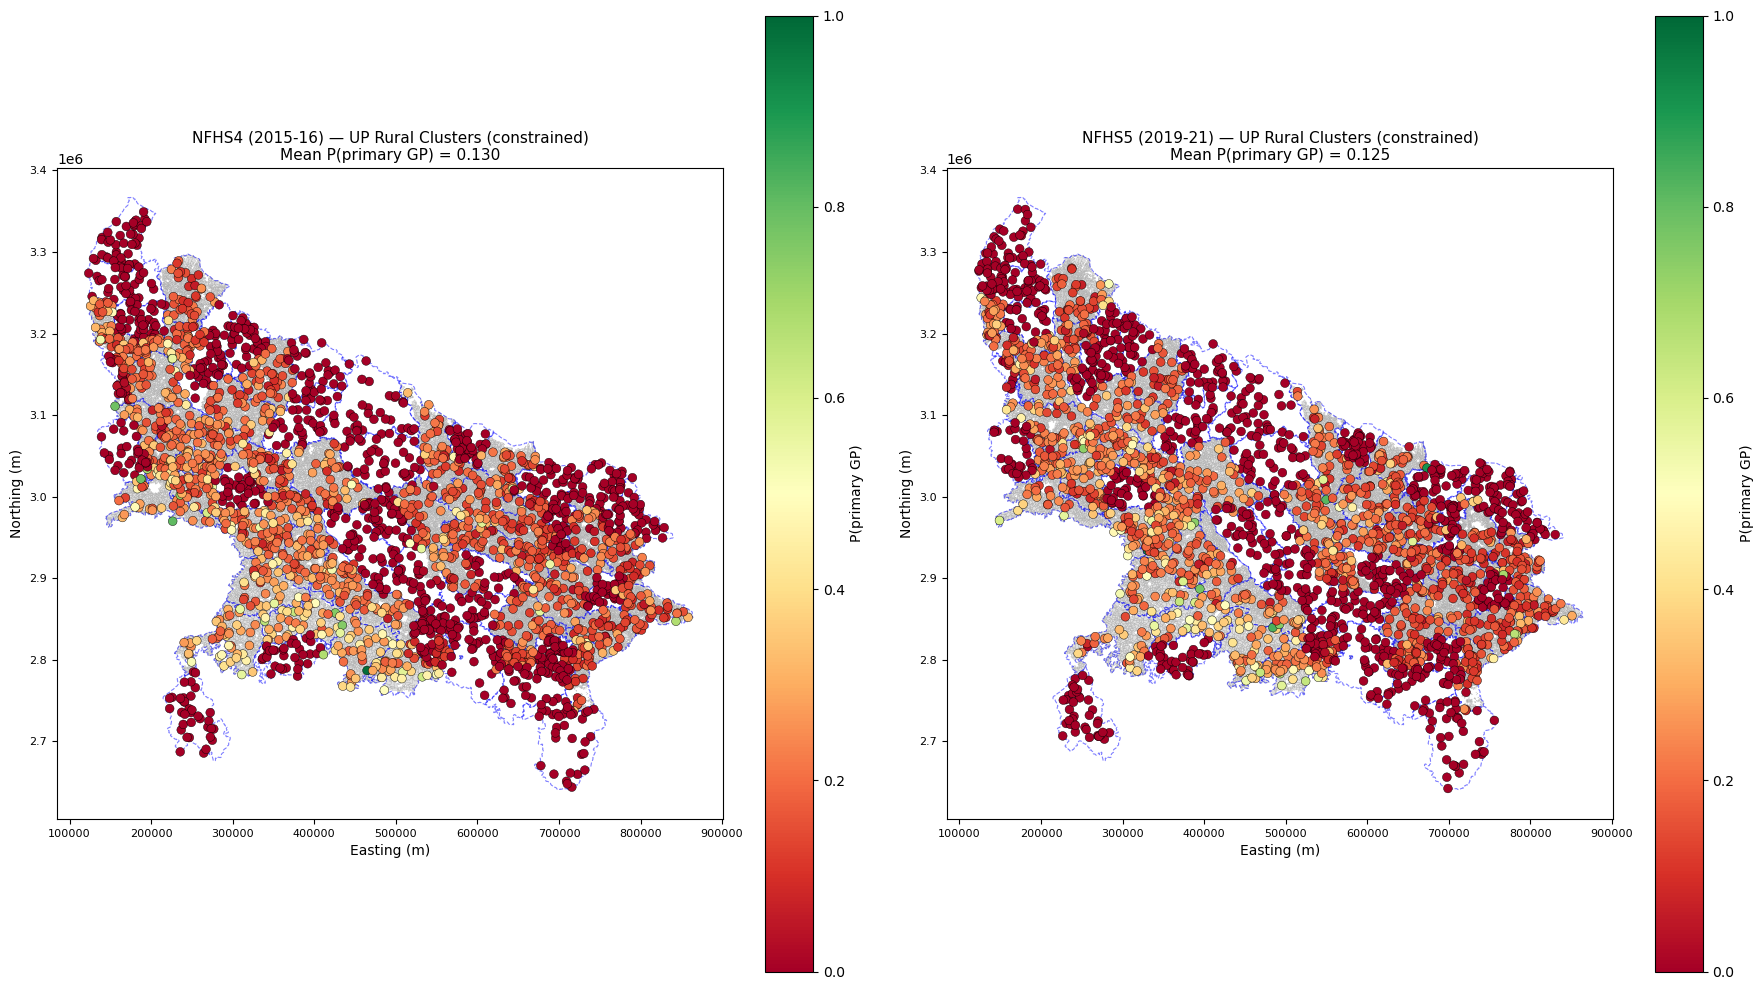

Map saved.


In [32]:
# =============================================================================
# CELL 26 — Visualisation: Full UP Map
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

for ax, mc_df, clusters_gdf, round_name in [
    (axes[0], mc_nfhs4_up, nfhs4_up, "NFHS4 (2015-16)"),
    (axes[1], mc_nfhs5_up, nfhs5_up, "NFHS5 (2019-21)")
]:
    gp_polygons_up.plot(
        ax=ax, color="lightgrey", edgecolor="darkgrey",
        linewidth=0.3, alpha=0.7
    )
    district_polygons_up.plot(
        ax=ax, color="none", edgecolor="blue",
        linewidth=0.8, linestyle="--", alpha=0.5
    )
    clusters_plot = clusters_gdf.merge(
        mc_df[["DHSCLUST", "primary_gp_prob", "n_gps_hit",
               "n_in_district"]],
        on="DHSCLUST", how="left"
    )
    scatter = ax.scatter(
        clusters_plot.geometry.x,
        clusters_plot.geometry.y,
        c=clusters_plot["primary_gp_prob"],
        cmap="RdYlGn", vmin=0, vmax=1,
        s=40, edgecolors="black", linewidth=0.3, zorder=5
    )
    plt.colorbar(scatter, ax=ax, label="P(primary GP)")
    ax.set_title(
        f"{round_name} — UP Rural Clusters (constrained)\n"
        f"Mean P(primary GP) = {mc_df['primary_gp_prob'].mean():.3f}",
        fontsize=11
    )
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(
    OUTPUT_MC_UP / "up_monte_carlo_constrained.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Map saved.")

In [34]:
# =============================================================================
# CELL 27 — Save Full UP Results
# =============================================================================

mc_nfhs4_up.to_csv(OUTPUT_MC_UP / "up_mc_nfhs4_constrained.csv", index=False)
mc_nfhs5_up.to_csv(OUTPUT_MC_UP / "up_mc_nfhs5_constrained.csv", index=False)

print("Saved:")
print(f"  {OUTPUT_MC_UP / 'up_mc_nfhs4_constrained.csv'}")
print(f"  {OUTPUT_MC_UP / 'up_mc_nfhs5_constrained.csv'}")
print(f"\nRows: NFHS4={len(mc_nfhs4_up)}, NFHS5={len(mc_nfhs5_up)}")


Saved:
  ../outputs/monte carlo simulation uttar pradesh/up_mc_nfhs4_constrained.csv
  ../outputs/monte carlo simulation uttar pradesh/up_mc_nfhs5_constrained.csv

Rows: NFHS4=2659, NFHS5=2661


In [35]:
# For each UP cluster, check what fraction of villages 
# within 5km buffer have GP codes

def compute_gp_coverage_in_buffer(clusters, all_villages, displacement_m):
    """
    For each cluster, compute the fraction of villages within 
    the displacement buffer that have a GP code assigned.
    Clusters where coverage = 100% are not affected by the LGD gap.
    """
    results = []
    
    clusters_proj = clusters.copy()
    clusters_proj["buffer"] = clusters_proj.geometry.buffer(displacement_m)
    buffer_gdf = gpd.GeoDataFrame(
        clusters_proj[["DHSCLUST", "buffer"]],
        geometry="buffer",
        crs=clusters_proj.crs
    )
    
    # Spatial join: find all villages within each buffer
    villages_in_buffer = gpd.sjoin(
        all_villages[["gp_lgd_code", "geometry"]],
        buffer_gdf,
        how="inner",
        predicate="intersects"
    )
    
    # For each cluster, compute GP coverage rate
    coverage = (
        villages_in_buffer
        .groupby("DHSCLUST")
        .agg(
            total_villages   = ("gp_lgd_code", "count"),
            villages_with_gp = ("gp_lgd_code", "notna().sum" if False
                                else lambda x: x.notna().sum())
        )
        .reset_index()
    )
    coverage["gp_coverage_rate"] = (
        coverage["villages_with_gp"] / coverage["total_villages"]
    )
    
    return coverage

print("Computing GP coverage within 5km buffer for all UP rural clusters...")
coverage_nfhs5 = compute_gp_coverage_in_buffer(
    nfhs5_up, up_villages_all, RURAL_DISPLACEMENT
)

print(f"\nCoverage rate distribution:")
bins   = [0, 0.25, 0.5, 0.75, 0.9, 1.01]
labels = ["0-25%", "25-50%", "50-75%", "75-90%", "100%"]
coverage_nfhs5["coverage_bin"] = pd.cut(
    coverage_nfhs5["gp_coverage_rate"], bins=bins, labels=labels
)
print(coverage_nfhs5["coverage_bin"].value_counts().sort_index())

# Clusters where ALL surrounding villages have GP codes
fully_covered = coverage_nfhs5[
    coverage_nfhs5["gp_coverage_rate"] == 1.0
]
print(f"\nClusters with 100% GP coverage in 5km buffer: {len(fully_covered)}")
print(f"As % of all UP rural clusters: {len(fully_covered)/len(nfhs5_up):.1%}")

Computing GP coverage within 5km buffer for all UP rural clusters...

Coverage rate distribution:
coverage_bin
0-25%        0
25-50%       0
50-75%       0
75-90%       0
100%      1806
Name: count, dtype: int64

Clusters with 100% GP coverage in 5km buffer: 1806
As % of all UP rural clusters: 67.9%


Computing GP coverage within 5km buffer for NFHS4 UP clusters...

Valid clusters (100% buffer GP coverage):
  NFHS4: 1864 of 2659 (70.1%)
  NFHS5: 1806 of 2661 (67.9%)

Districts represented in valid NFHS5 clusters:
DHSREGNA
Amethi                          43
Balrampur                       42
Gonda                           42
Basti                           42
Jaunpur                         42
Ghazipur                        42
Kanpur Dehat                    41
Chitrakoot                      41
Bahraich                        41
Azamgarh                        41
Ballia                          41
Bara Banki                      40
Ambedkar Nagar                  40
Deoria                          40
Hardoi                          39
Fatehpur                        39
Faizabad                        39
Chandauli                       39
Banda                           38
Etah                            38
Kannauj                         37
Auraiya                         37
Gorak

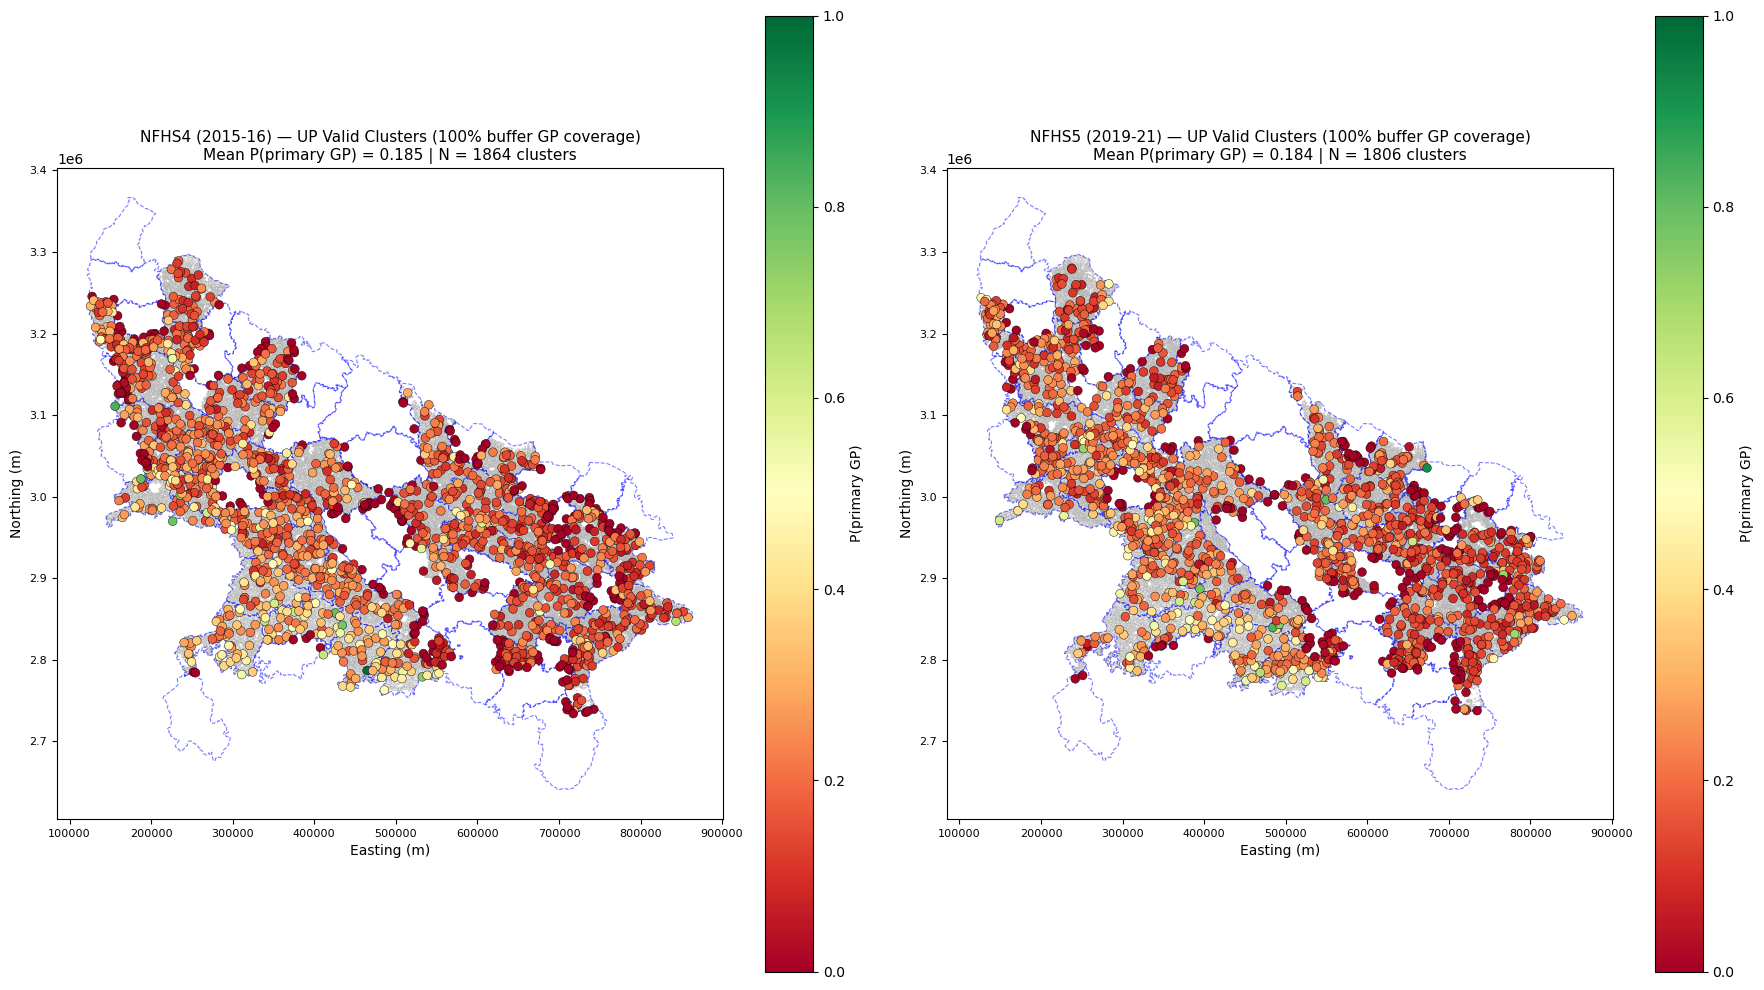

Map saved.

Saved:
  ../outputs/monte carlo simulation uttar pradesh/up_mc_nfhs4_valid_clusters_constrained.csv
  ../outputs/monte carlo simulation uttar pradesh/up_mc_nfhs5_valid_clusters_constrained.csv

Rows: NFHS4=1864, NFHS5=1806


In [36]:
# =============================================================================
# CELL 28 — Monte Carlo for UP Clusters with Full GP Coverage in Buffer
# =============================================================================
# Addresses the LGD coverage gap issue: re-runs the Monte Carlo only for
# clusters where ALL villages within the 5km displacement buffer have a
# valid GP code assigned. For these clusters, P(primary GP) reflects genuine
# spatial displacement uncertainty rather than missing LGD data, making
# results directly comparable to Rajasthan.
#
# Note: coverage_nfhs5 was computed in the previous cell. We run the same
# coverage filter for NFHS4 here before running both.

# ── Step 1: Compute buffer GP coverage for NFHS4 ─────────────────────────────
print("Computing GP coverage within 5km buffer for NFHS4 UP clusters...")
coverage_nfhs4 = compute_gp_coverage_in_buffer(
    nfhs4_up, up_villages_all, RURAL_DISPLACEMENT
)

# ── Step 2: Filter to fully-covered clusters ──────────────────────────────────
# "Fully covered" = all villages within 5km buffer have a GP code
# (100% coverage rate in the buffer analysis)
valid_nfhs4 = nfhs4_up[
    nfhs4_up["DHSCLUST"].isin(
        coverage_nfhs4[coverage_nfhs4["gp_coverage_rate"] == 1.0]["DHSCLUST"]
    )
].copy()

valid_nfhs5 = nfhs5_up[
    nfhs5_up["DHSCLUST"].isin(
        coverage_nfhs5[coverage_nfhs5["gp_coverage_rate"] == 1.0]["DHSCLUST"]
    )
].copy()

print(f"\nValid clusters (100% buffer GP coverage):")
print(f"  NFHS4: {len(valid_nfhs4)} of {len(nfhs4_up)} ({len(valid_nfhs4)/len(nfhs4_up):.1%})")
print(f"  NFHS5: {len(valid_nfhs5)} of {len(nfhs5_up)} ({len(valid_nfhs5)/len(nfhs5_up):.1%})")

print(f"\nDistricts represented in valid NFHS5 clusters:")
print(valid_nfhs5["DHSREGNA"].value_counts().to_string())

# ── Step 3: Run constrained Monte Carlo on valid clusters only ────────────────
print("\nRunning constrained Monte Carlo on valid UP clusters...")
print(f"NFHS4: {len(valid_nfhs4)} clusters × {N_SIMULATIONS} simulations")
print(f"NFHS5: {len(valid_nfhs5)} clusters × {N_SIMULATIONS} simulations")

mc_nfhs4_up_valid = run_monte_carlo_constrained(
    valid_nfhs4, gp_polygons_up, district_polygons_up,
    N_SIMULATIONS, RANDOM_SEED
)
mc_nfhs5_up_valid = run_monte_carlo_constrained(
    valid_nfhs5, gp_polygons_up, district_polygons_up,
    N_SIMULATIONS, RANDOM_SEED
)
print("\nDone.")

# ── Step 4: Summary statistics ────────────────────────────────────────────────
print("\n" + "=" * 70)
print("MONTE CARLO RESULTS: UP CLUSTERS WITH FULL BUFFER GP COVERAGE")
print("=" * 70)

for name, df in [("NFHS4 (2015-16)", mc_nfhs4_up_valid),
                  ("NFHS5 (2019-21)", mc_nfhs5_up_valid)]:
    rural = df[df["URBAN_RURA"] == "R"].copy()
    print(f"\n── {name} ──────────────────────────────────────")
    print(f"Total valid clusters:              {len(rural)}")
    print(f"Mean P(primary GP):                {rural['primary_gp_prob'].mean():.3f}")
    print(f"Median P(primary GP):              {rural['primary_gp_prob'].median():.3f}")
    print(f"Clusters with P > 0.9:             "
          f"{(rural['primary_gp_prob'] > 0.9).sum()} "
          f"({(rural['primary_gp_prob'] > 0.9).mean():.1%})")
    print(f"Clusters with P > 0.8:             "
          f"{(rural['primary_gp_prob'] > 0.8).sum()} "
          f"({(rural['primary_gp_prob'] > 0.8).mean():.1%})")
    print(f"Clusters with P > 0.5:             "
          f"{(rural['primary_gp_prob'] > 0.5).sum()} "
          f"({(rural['primary_gp_prob'] > 0.5).mean():.1%})")
    print(f"Mean GPs hit per cluster:          {rural['n_gps_hit'].mean():.2f}")
    print(f"Mean sims outside district:        {rural['n_outside_district'].mean():.1f}")
    print(f"Mean sims outside any GP:          {rural['n_outside_any_gp'].mean():.1f}")
    print(f"\nP(primary GP) distribution:")
    bins   = [0, 0.25, 0.5, 0.75, 0.9, 1.01]
    labels = ["0-25%", "25-50%", "50-75%", "75-90%", ">90%"]
    rural["prob_bin"] = pd.cut(rural["primary_gp_prob"], bins=bins, labels=labels)
    print(rural["prob_bin"].value_counts().sort_index().to_string())

print(f"\n── P(primary GP) by district (NFHS5 valid clusters) ──")
district_summary = (
    mc_nfhs5_up_valid[mc_nfhs5_up_valid["URBAN_RURA"] == "R"]
    .groupby("DHSREGNA")["primary_gp_prob"]
    .agg(["mean", "count"])
    .round(3)
    .sort_values("mean", ascending=False)
)
district_summary.columns = ["Mean P(primary GP)", "N clusters"]
print(district_summary.to_string())



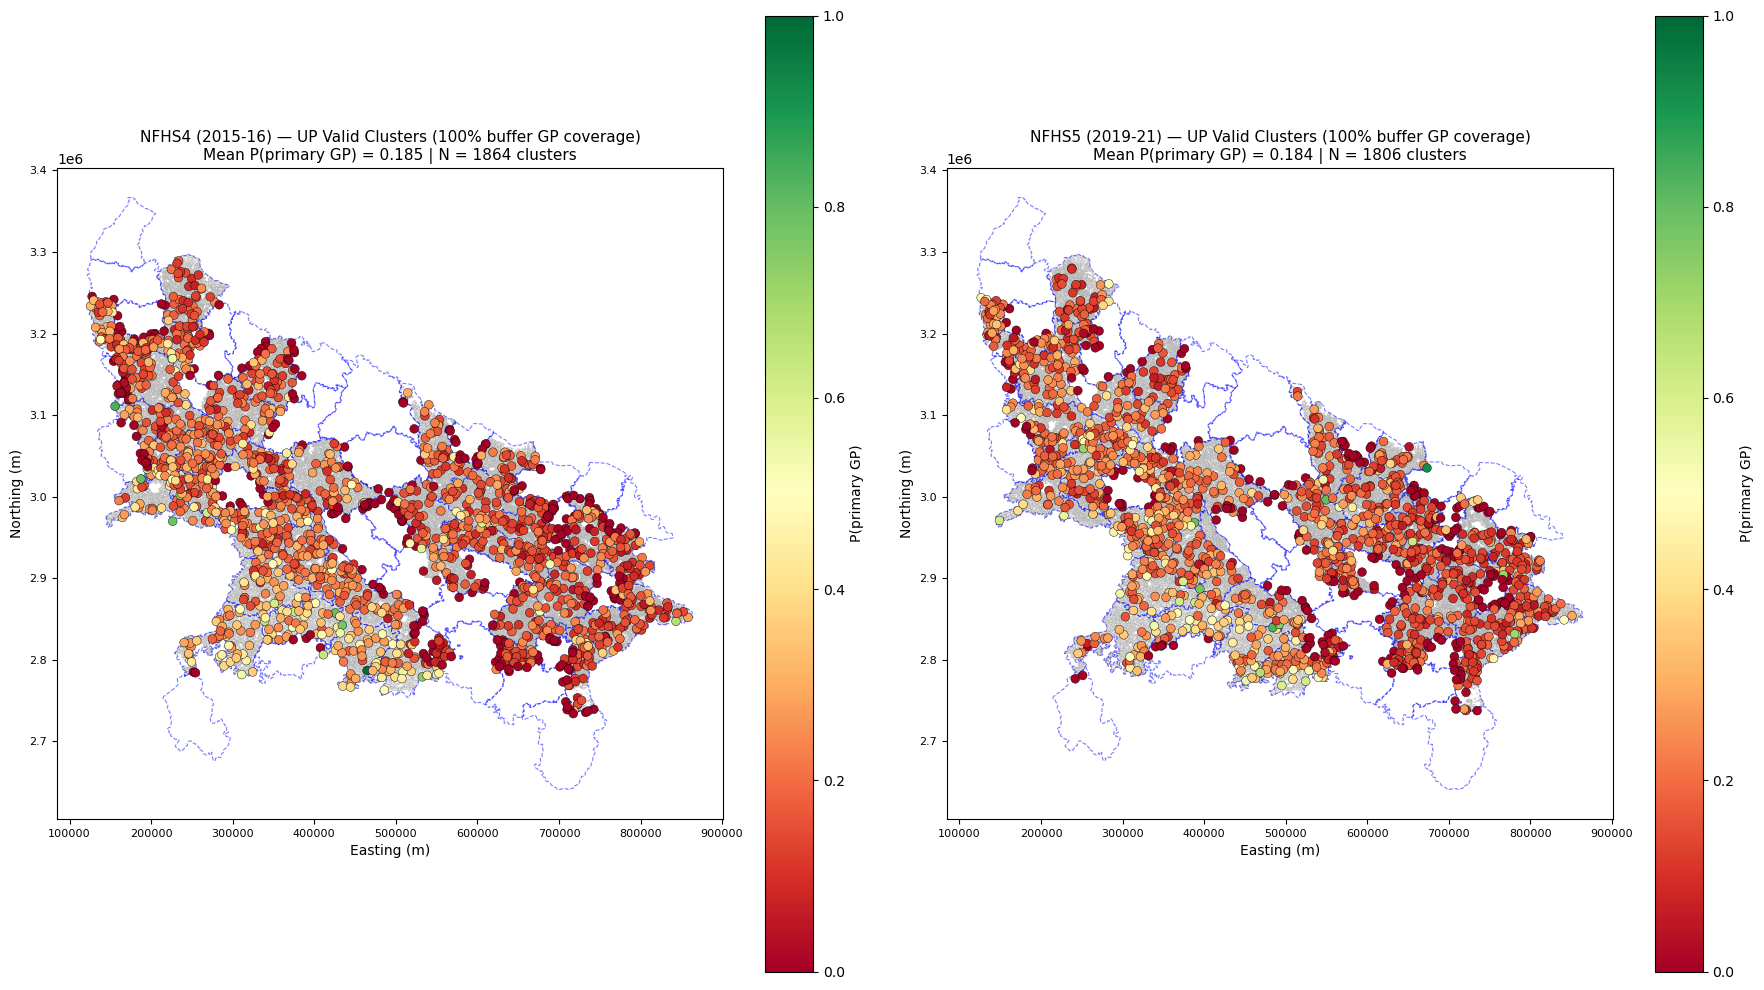

Map saved.

Saved:
  ../outputs/monte carlo simulation uttar pradesh/up_mc_nfhs4_valid_clusters_constrained.csv
  ../outputs/monte carlo simulation uttar pradesh/up_mc_nfhs5_valid_clusters_constrained.csv

Rows: NFHS4=1864, NFHS5=1806


In [37]:
# ── Step 5: Map ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

for ax, mc_df, clusters_gdf, round_name in [
    (axes[0], mc_nfhs4_up_valid, valid_nfhs4, "NFHS4 (2015-16)"),
    (axes[1], mc_nfhs5_up_valid, valid_nfhs5, "NFHS5 (2019-21)")
]:
    gp_polygons_up.plot(
        ax=ax, color="lightgrey", edgecolor="darkgrey",
        linewidth=0.3, alpha=0.7
    )
    district_polygons_up.plot(
        ax=ax, color="none", edgecolor="blue",
        linewidth=0.8, linestyle="--", alpha=0.5
    )
    clusters_plot = clusters_gdf.merge(
        mc_df[["DHSCLUST", "primary_gp_prob", "n_gps_hit"]],
        on="DHSCLUST", how="left"
    )
    scatter = ax.scatter(
        clusters_plot.geometry.x,
        clusters_plot.geometry.y,
        c=clusters_plot["primary_gp_prob"],
        cmap="RdYlGn", vmin=0, vmax=1,
        s=40, edgecolors="black", linewidth=0.3, zorder=5
    )
    plt.colorbar(scatter, ax=ax, label="P(primary GP)")
    ax.set_title(
        f"{round_name} — UP Valid Clusters (100% buffer GP coverage)\n"
        f"Mean P(primary GP) = {mc_df['primary_gp_prob'].mean():.3f} | "
        f"N = {len(clusters_gdf)} clusters",
        fontsize=11
    )
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(
    OUTPUT_MC_UP / "up_monte_carlo_valid_clusters_constrained.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Map saved.")

# ── Step 6: Save ──────────────────────────────────────────────────────────────
mc_nfhs4_up_valid.to_csv(
    OUTPUT_MC_UP / "up_mc_nfhs4_valid_clusters_constrained.csv", index=False
)
mc_nfhs5_up_valid.to_csv(
    OUTPUT_MC_UP / "up_mc_nfhs5_valid_clusters_constrained.csv", index=False
)
print(f"\nSaved:")
print(f"  {OUTPUT_MC_UP / 'up_mc_nfhs4_valid_clusters_constrained.csv'}")
print(f"  {OUTPUT_MC_UP / 'up_mc_nfhs5_valid_clusters_constrained.csv'}")
print(f"\nRows: NFHS4={len(mc_nfhs4_up_valid)}, NFHS5={len(mc_nfhs5_up_valid)}")

In [38]:
# =============================================================================
# RAJASTHAN — Monte Carlo for clusters with FULL village→GP coverage in buffer
# =============================================================================
# This mirrors the UP approach:
#   1. Compute GP coverage within each rural Rajasthan cluster's 5km buffer.
#   2. Keep only clusters where ALL villages in the buffer have valid GP codes.
#   3. Re-run constrained Monte Carlo only on those valid clusters.
#   4. Save:
#        rajasthan_mc_nfhs4_constrained_valid.csv
#        rajasthan_mc_nfhs5_constrained_valid.csv
#
# Required objects already in memory:
#   nfhs4_rj
#   nfhs5_rj
#   gp_polygons_rj
#   district_polygons_rj
#   N_SIMULATIONS
#   RANDOM_SEED
#   RURAL_DISPLACEMENT
#   OUTPUT_MC_RJ
#   compute_gp_coverage_in_buffer()
#   run_monte_carlo_constrained()
#
# Required village polygon object:
#   This code assumes your Rajasthan village polygon object is called:
#       rj_villages_all
#   If yours has a different name, change RAJASTHAN_VILLAGES_ALL below.
# =============================================================================

# ── Step 0: Set Rajasthan village polygon object ─────────────────────────────
# Change this if your Rajasthan village polygon object has another name.
RAJASTHAN_VILLAGES_ALL = rj_villages_all

print("=" * 80)
print("RAJASTHAN VALID-ONLY MONTE CARLO")
print("=" * 80)

print("\nInput cluster counts:")
print(f"  NFHS4 Rajasthan rural clusters: {len(nfhs4_rj)}")
print(f"  NFHS5 Rajasthan rural clusters: {len(nfhs5_rj)}")

print("\nVillage polygon object:")
print(f"  Rows: {len(RAJASTHAN_VILLAGES_ALL)}")
print(f"  CRS:  {RAJASTHAN_VILLAGES_ALL.crs}")


# ── Step 1: Compute buffer GP coverage for NFHS4 and NFHS5 ───────────────────
print("\nComputing GP coverage within 5km buffer for NFHS4 Rajasthan clusters...")
coverage_nfhs4_rj = compute_gp_coverage_in_buffer(
    nfhs4_rj,
    RAJASTHAN_VILLAGES_ALL,
    RURAL_DISPLACEMENT
)

print("\nComputing GP coverage within 5km buffer for NFHS5 Rajasthan clusters...")
coverage_nfhs5_rj = compute_gp_coverage_in_buffer(
    nfhs5_rj,
    RAJASTHAN_VILLAGES_ALL,
    RURAL_DISPLACEMENT
)

print("\nCoverage output columns, NFHS4:")
print(coverage_nfhs4_rj.columns.tolist())

print("\nCoverage output columns, NFHS5:")
print(coverage_nfhs5_rj.columns.tolist())


# ── Step 2: Filter to fully-covered clusters ─────────────────────────────────
# Fully covered = all villages in the 5km displacement buffer have a valid GP code.
# In the UP code, this is gp_coverage_rate == 1.0.

valid_nfhs4_rj = nfhs4_rj[
    nfhs4_rj["DHSCLUST"].isin(
        coverage_nfhs4_rj.loc[
            coverage_nfhs4_rj["gp_coverage_rate"].eq(1.0),
            "DHSCLUST"
        ]
    )
].copy()

valid_nfhs5_rj = nfhs5_rj[
    nfhs5_rj["DHSCLUST"].isin(
        coverage_nfhs5_rj.loc[
            coverage_nfhs5_rj["gp_coverage_rate"].eq(1.0),
            "DHSCLUST"
        ]
    )
].copy()

print("\nValid clusters with 100% buffer village→GP coverage:")
print(f"  NFHS4: {len(valid_nfhs4_rj)} of {len(nfhs4_rj)} "
      f"({len(valid_nfhs4_rj) / len(nfhs4_rj):.1%})")
print(f"  NFHS5: {len(valid_nfhs5_rj)} of {len(nfhs5_rj)} "
      f"({len(valid_nfhs5_rj) / len(nfhs5_rj):.1%})")

print("\nDistricts represented in valid NFHS4 clusters:")
print(valid_nfhs4_rj["DHSREGNA"].value_counts().sort_index().to_string())

print("\nDistricts represented in valid NFHS5 clusters:")
print(valid_nfhs5_rj["DHSREGNA"].value_counts().sort_index().to_string())


# ── Step 3: Save buffer coverage diagnostics ─────────────────────────────────
coverage_nfhs4_rj_out = OUTPUT_MC_RJ / "rajasthan_nfhs4_buffer_gp_coverage.csv"
coverage_nfhs5_rj_out = OUTPUT_MC_RJ / "rajasthan_nfhs5_buffer_gp_coverage.csv"

coverage_nfhs4_rj.to_csv(coverage_nfhs4_rj_out, index=False)
coverage_nfhs5_rj.to_csv(coverage_nfhs5_rj_out, index=False)

print("\nSaved buffer GP coverage diagnostics:")
print(f"  {coverage_nfhs4_rj_out}")
print(f"  {coverage_nfhs5_rj_out}")


# ── Step 4: Run constrained Monte Carlo on valid clusters only ───────────────
print("\nRunning constrained Monte Carlo on valid Rajasthan clusters...")
print(f"NFHS4: {len(valid_nfhs4_rj)} clusters × {N_SIMULATIONS} simulations")
print(f"NFHS5: {len(valid_nfhs5_rj)} clusters × {N_SIMULATIONS} simulations")

mc_nfhs4_rj_valid = run_monte_carlo_constrained(
    valid_nfhs4_rj,
    gp_polygons_rj,
    district_polygons_rj,
    N_SIMULATIONS,
    RANDOM_SEED
)

mc_nfhs5_rj_valid = run_monte_carlo_constrained(
    valid_nfhs5_rj,
    gp_polygons_rj,
    district_polygons_rj,
    N_SIMULATIONS,
    RANDOM_SEED
)

print("\nMonte Carlo complete.")


# ── Step 5: Merge coverage metadata back onto valid MC outputs ───────────────
coverage_cols = [
    c for c in [
        "DHSCLUST",
        "n_villages_in_buffer",
        "n_villages_with_gp",
        "n_villages_missing_gp",
        "gp_coverage_rate"
    ]
    if c in coverage_nfhs4_rj.columns
]

if "DHSCLUST" in coverage_cols:
    mc_nfhs4_rj_valid = mc_nfhs4_rj_valid.merge(
        coverage_nfhs4_rj[coverage_cols],
        on="DHSCLUST",
        how="left"
    )

coverage_cols5 = [
    c for c in [
        "DHSCLUST",
        "n_villages_in_buffer",
        "n_villages_with_gp",
        "n_villages_missing_gp",
        "gp_coverage_rate"
    ]
    if c in coverage_nfhs5_rj.columns
]

if "DHSCLUST" in coverage_cols5:
    mc_nfhs5_rj_valid = mc_nfhs5_rj_valid.merge(
        coverage_nfhs5_rj[coverage_cols5],
        on="DHSCLUST",
        how="left"
    )


# ── Step 6: Summary statistics ───────────────────────────────────────────────
print("\n" + "=" * 70)
print("MONTE CARLO RESULTS: RAJASTHAN CLUSTERS WITH FULL BUFFER GP COVERAGE")
print("=" * 70)

for name, df in [
    ("NFHS4 (2015-16)", mc_nfhs4_rj_valid),
    ("NFHS5 (2019-21)", mc_nfhs5_rj_valid)
]:
    rural = df[df["URBAN_RURA"] == "R"].copy()

    print(f"\n── {name} ──────────────────────────────────────")
    print(f"Total valid clusters:              {len(rural)}")

    if len(rural) == 0:
        print("No valid clusters; skipping summary.")
        continue

    print(f"Mean P(primary GP):                {rural['primary_gp_prob'].mean():.3f}")
    print(f"Median P(primary GP):              {rural['primary_gp_prob'].median():.3f}")

    print(f"Clusters with P > 0.9:             "
          f"{(rural['primary_gp_prob'] > 0.9).sum()} "
          f"({(rural['primary_gp_prob'] > 0.9).mean():.1%})")

    print(f"Clusters with P > 0.8:             "
          f"{(rural['primary_gp_prob'] > 0.8).sum()} "
          f"({(rural['primary_gp_prob'] > 0.8).mean():.1%})")

    print(f"Clusters with P > 0.5:             "
          f"{(rural['primary_gp_prob'] > 0.5).sum()} "
          f"({(rural['primary_gp_prob'] > 0.5).mean():.1%})")

    print(f"Mean GPs hit per cluster:          {rural['n_gps_hit'].mean():.2f}")
    print(f"Mean sims outside district:        {rural['n_outside_district'].mean():.1f}")
    print(f"Mean sims outside any GP:          {rural['n_outside_any_gp'].mean():.1f}")

    if "gp_coverage_rate" in rural.columns:
        print(f"Mean village→GP coverage rate:     {rural['gp_coverage_rate'].mean():.3f}")
        print(f"Min village→GP coverage rate:      {rural['gp_coverage_rate'].min():.3f}")

    print(f"\nP(primary GP) distribution:")
    bins   = [0, 0.25, 0.5, 0.75, 0.9, 1.01]
    labels = ["0-25%", "25-50%", "50-75%", "75-90%", ">90%"]
    rural["prob_bin"] = pd.cut(rural["primary_gp_prob"], bins=bins, labels=labels)
    print(rural["prob_bin"].value_counts().sort_index().to_string())


print(f"\n── P(primary GP) by district (NFHS4 valid clusters) ──")
if len(mc_nfhs4_rj_valid) > 0:
    district_summary_nfhs4 = (
        mc_nfhs4_rj_valid[mc_nfhs4_rj_valid["URBAN_RURA"] == "R"]
        .groupby("DHSREGNA")["primary_gp_prob"]
        .agg(["mean", "count"])
        .round(3)
        .sort_values("mean", ascending=False)
    )
    district_summary_nfhs4.columns = ["Mean P(primary GP)", "N clusters"]
    print(district_summary_nfhs4.to_string())

print(f"\n── P(primary GP) by district (NFHS5 valid clusters) ──")
if len(mc_nfhs5_rj_valid) > 0:
    district_summary_nfhs5 = (
        mc_nfhs5_rj_valid[mc_nfhs5_rj_valid["URBAN_RURA"] == "R"]
        .groupby("DHSREGNA")["primary_gp_prob"]
        .agg(["mean", "count"])
        .round(3)
        .sort_values("mean", ascending=False)
    )
    district_summary_nfhs5.columns = ["Mean P(primary GP)", "N clusters"]
    print(district_summary_nfhs5.to_string())


# ── Step 7: Save updated valid-only Rajasthan Monte Carlo outputs ────────────
OUT_NFHS4_VALID = OUTPUT_MC_RJ / "rajasthan_mc_nfhs4_constrained_valid.csv"
OUT_NFHS5_VALID = OUTPUT_MC_RJ / "rajasthan_mc_nfhs5_constrained_valid.csv"

mc_nfhs4_rj_valid.to_csv(OUT_NFHS4_VALID, index=False)
mc_nfhs5_rj_valid.to_csv(OUT_NFHS5_VALID, index=False)

print("\nSaved valid-only constrained Monte Carlo outputs:")
print(f"  {OUT_NFHS4_VALID}")
print(f"  {OUT_NFHS5_VALID}")

print("\nRows:")
print(f"  NFHS4 original: {len(nfhs4_rj)}")
print(f"  NFHS4 valid:    {len(mc_nfhs4_rj_valid)}")
print(f"  NFHS5 original: {len(nfhs5_rj)}")
print(f"  NFHS5 valid:    {len(mc_nfhs5_rj_valid)}")

print("\nDone.")

RAJASTHAN VALID-ONLY MONTE CARLO

Input cluster counts:
  NFHS4 Rajasthan rural clusters: 1190
  NFHS5 Rajasthan rural clusters: 1163

Village polygon object:
  Rows: 44976
  CRS:  EPSG:32644

Computing GP coverage within 5km buffer for NFHS4 Rajasthan clusters...

Computing GP coverage within 5km buffer for NFHS5 Rajasthan clusters...

Coverage output columns, NFHS4:
['DHSCLUST', 'total_villages', 'villages_with_gp', 'gp_coverage_rate']

Coverage output columns, NFHS5:
['DHSCLUST', 'total_villages', 'villages_with_gp', 'gp_coverage_rate']

Valid clusters with 100% buffer village→GP coverage:
  NFHS4: 1189 of 1190 (99.9%)
  NFHS5: 1163 of 1163 (100.0%)

Districts represented in valid NFHS4 clusters:
DHSREGNA
Ajmer             43
Alwar             35
Banswara          39
Baran             34
Barmer            40
Bharatpur         34
Bhilwara          33
Bikaner           42
Bundi             34
Chittaurgarh      35
Churu             30
Dausa             37
Dhaulpur          34
Dungarpur